# Proyecto 2 — Análisis exploratorio
## Biohub: *Cell Tracking During Development*

**CC3084 Data Science · Universidad del Valle de Guatemala · Semestre II 2026**
Isabella Obando (23074) · Anthony Lou (23410) · Fabian Prado (23427) · Fernando Mendoza (19644)

Este notebook acompaña al informe *Proyecto 2. Análisis Exploratorio* y sigue su misma numeración
(secciones 4 a 6). Las secciones 1 a 3 del informe (situación problemática, problema científico y
objetivos) no requieren código y solo están en el documento.

**Cambios respecto a la versión del informe (07/09/2026).** Esa versión corrió en Colab y descargaba
los archivos con la API de Kaggle. Por los errores 404 y las descargas incompletas, el análisis se
limitó a 30 muestras. Esta versión corre dentro de Kaggle, con los datos montados, y usa **las 199
muestras** de `train/`. Además:

- Se agregan análisis para los puntos que el informe dejó abiertos: atípicos extremos (5.7),
  saltos colectivos a nivel de instante (5.7.b), deriva direccional (5.6), comparación estadística
  entre embriones (5.5) e intensidad en varias muestras (5.10.b).
- Dos conclusiones del informe cambian con los datos completos: **sí hay deriva direccional** (5.6) y
  **la atenuación del 92% no es representativa** (5.10.b).
- Se agrega una tabla de estabilidad 30 vs 199 muestras (5.11).
- Se corrigen artefactos de binning en los histogramas de profundidad Z.

<details><summary><b>Cómo correrlo</b></summary>

1. Aceptar las reglas de la competencia (*Join Competition*).
2. En la pestaña **Code** de la competencia: **New Notebook** → *File → Import Notebook*.
3. Verificar que la competencia aparezca en el panel **Input**.
4. *Settings → Internet: On* (solo para instalar `zarr>=3`).
5. *Run All*. No necesita GPU.

Fuera de Kaggle basta con definir la variable de entorno `BIOHUB_DATA` con una carpeta que tenga
la misma estructura (`train/*.zarr`, `train/*.geff`).
</details>

# 4. Descripción de los datos

## 4.1 Origen y carga

Los datos provienen de la competencia *Biohub — Cell Tracking During Development* (Kaggle). Cada
muestra es un par:

| Componente | Contenido | Uso en este análisis |
|---|---|---|
| `{muestra}.zarr` | video 3D+tiempo, arreglo `(T, Z, Y, X) = (100, 64, 256, 256)` `uint16` | metadatos de todas las muestras; volúmenes de una submuestra (5.10) |
| `{muestra}.geff` | grafo de linaje de referencia: nodos con `(t, z, y, x)` y aristas entre instantes | todo el análisis cuantitativo |

Los nombres siguen el patrón `{embryo_id}_{field_of_view}`. Los conjuntos de entrenamiento y prueba
no comparten embriones. Dentro de Kaggle los datos (87.6 GB) se montan en solo lectura, así que no se
descarga nada: `zarr` lee directamente los fragmentos que necesita.

In [31]:
# zarr>=3 es obligatorio: los arreglos usan la especificación Zarr v3 (zarr.json, chunks en c/i/j/k/l).
# La imagen de Kaggle puede traer zarr 2.x; solo se instala si hace falta (requiere Internet: On).
import importlib.metadata as _md
try:
    _zv = _md.version("zarr")
except _md.PackageNotFoundError:
    _zv = "0"
if int(_zv.split(".")[0]) < 3:
    !pip install -q --upgrade "zarr>=3"

In [32]:
import os, json, time
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import zarr
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

print("zarr", zarr.__version__, "| pandas", pd.__version__)

zarr 3.4.1 | pandas 2.3.3


In [33]:
COMPETITION = "biohub-cell-tracking-during-development"


def encontrar_datos():
    """Ubica la carpeta de la competencia montada por Kaggle.

    Según la versión del entorno, Kaggle la monta en /kaggle/input/<nombre> o en
    /kaggle/input/competitions/<nombre>; se prueban ambas y, por si acaso, cualquier
    carpeta de /kaggle/input que contenga un train/."""
    if os.environ.get("BIOHUB_DATA"):
        return Path(os.environ["BIOHUB_DATA"])
    raiz = Path("/kaggle/input")
    candidatos = [raiz / COMPETITION, raiz / "competitions" / COMPETITION]
    candidatos += [p.parent for p in raiz.glob("*/train")] + [p.parent for p in raiz.glob("*/*/train")]
    for c in candidatos:
        if (c / "train").is_dir():
            return c
    raise FileNotFoundError(
        "No se encontró la competencia en /kaggle/input. Agrégala en el panel 'Input' del notebook.")


DATA_DIR  = encontrar_datos()
TRAIN_DIR = DATA_DIR / "train"

# Con los datos montados ya no hay costo de descarga: se pueden usar TODAS las muestras.
# Poner un número para limitar (p. ej. 15) si se quiere iterar más rápido.
SAMPLES_PER_EMBRYO = None   # None = todas las muestras de cada embrión
IMAGE_BUDGET_MB    = 250    # tope de memoria para el volumen de imagen que se carga

# Escala física del vóxel (Z, Y, X) en micras/píxel, documentada por los organizadores.
VOXEL_UM = np.array([1.625, 0.40625, 0.40625])

print("Datos en:", DATA_DIR)
print("Contenido:", sorted(p.name for p in DATA_DIR.iterdir()))

Datos en: /kaggle/input/competitions/biohub-cell-tracking-during-development
Contenido: ['sample_submission.csv', 'test', 'train']


In [34]:
# --- Selección de muestras ---------------------------------------------------
# Una muestra es válida si tiene su imagen (.zarr) y su grafo (.geff) pareados.
# test/ contiene copias de train sin anotaciones, así que no se usa en el EDA.
zarr_stems = {p.name[:-5] for p in TRAIN_DIR.glob("*.zarr")}
geff_stems = {p.name[:-5] for p in TRAIN_DIR.glob("*.geff")}
paired = sorted(zarr_stems & geff_stems)

print(f".zarr: {len(zarr_stems)} | .geff: {len(geff_stems)} | pareadas: {len(paired)}")
if zarr_stems ^ geff_stems:
    print("Sin pareja (se excluyen):", sorted(zarr_stems ^ geff_stems)[:10])

by_embryo = defaultdict(list)
for stem in paired:
    by_embryo[stem.split("_")[0]].append(stem)

SAMPLES = []
for embryo in sorted(by_embryo, key=lambda e: -len(by_embryo[e])):
    SAMPLES += sorted(by_embryo[embryo])[:SAMPLES_PER_EMBRYO]

print(f"\nMuestras disponibles por embrión:")
for e, s in sorted(by_embryo.items(), key=lambda kv: -len(kv[1])):
    print(f"  {e}: {len(s)}")
print(f"\nMuestras seleccionadas: {len(SAMPLES)}")

.zarr: 199 | .geff: 199 | pareadas: 199

Muestras disponibles por embrión:
  6bba: 128
  44b6: 71

Muestras seleccionadas: 199


## 4.3 Construcción de las tablas analíticas

Los grafos `.geff` no vienen en formato tabular. El primer paso del preprocesamiento los convierte en
cuatro tablas con granularidades distintas:

| Tabla | Unidad de observación | Responde a |
|---|---|---|
| `df_samples` | una muestra (*field of view*) | volumen y cobertura de la anotación |
| `df_nodes` | una célula anotada en un instante | distribución espacial y temporal |
| `df_edges` | un enlace entre dos instantes consecutivos | dinámica del movimiento |
| `df_linajes` | un linaje (componente conexa del grafo, sección 5.9) | longitud de las trayectorias |

Pasos aplicados:

1. **Grafo → tabla.** Se leen `nodes/ids`, `nodes/props/{t,z,y,x}/values` y `edges/ids`.
2. **Reindexado.** Las aristas referencian *ids* de nodo, no posiciones. Se construye un mapa
   id → índice y se descartan las aristas con extremos inexistentes (la verificación confirma que no
   hay ninguna).
3. **Conversión a micras.** `z_um, y_um, x_um` = coordenada × escala del vóxel. Sin este paso, las
   distancias quedarían distorsionadas por la anisotropía 4:1 en Z.
4. **Variables derivadas.** Grados de entrada y salida, `es_division`, `tipo_temporal`, el
   desplazamiento por eje y la distancia 3D de cada arista. En esta versión cada arista guarda también
   los *ids* y la posición de origen, lo que permite seguir trayectorias en el análisis de atípicos.

Antes de construir las tablas se aplica un control de calidad a cada muestra: arreglos completos,
*ids* únicos y `t` no constante.

In [35]:
# --- Lectura de imagen (.zarr) y grafo (.geff) -------------------------------
def tiene_meta(d):
    return (Path(d) / "zarr.json").exists() or (Path(d) / ".zarray").exists()


def zarr_json(path):
    """Lee la metadata de un arreglo zarr (v3: zarr.json, v2: .zarray)."""
    p3, p2 = Path(path) / "zarr.json", Path(path) / ".zarray"
    if p3.exists():
        m = json.loads(p3.read_text())
        if m.get("node_type") == "group":
            return None
        return {"shape": tuple(m["shape"]),
                "dtype": str(m.get("data_type", m.get("dtype"))),
                "chunks": tuple(m["chunk_grid"]["configuration"]["chunk_shape"]),
                "encoding": m.get("chunk_key_encoding", {"name": "default"}),
                "raw": m}
    if p2.exists():
        m = json.loads(p2.read_text())
        return {"shape": tuple(m["shape"]), "dtype": str(m["dtype"]),
                "chunks": tuple(m["chunks"]),
                "encoding": {"name": "v2", "configuration": {"separator": "."}},
                "raw": m}
    return None


def image_levels(stem):
    """Niveles de la pirámide multiescala disponibles, con su metadata."""
    root = TRAIN_DIR / f"{stem}.zarr"
    out = {}
    if not root.exists():
        return out
    for d in sorted(root.iterdir()):
        if d.is_dir():
            m = zarr_json(d)
            if m:
                out[d.name] = m
    return out


def read_geff(stem):
    """Lee un grafo .geff -> (atributos, ids de nodo, props dict, aristas)."""
    g = TRAIN_DIR / f"{stem}.geff"
    attrs = {}
    try:
        attrs = dict(zarr.open_group(str(g), mode="r").attrs)
    except Exception:
        pass

    node_ids = np.asarray(zarr.open(str(g / "nodes" / "ids"), mode="r")[:])
    props = {}
    for name in ("t", "z", "y", "x"):
        p = g / "nodes" / "props" / name / "values"
        if tiene_meta(p):
            props[name] = np.asarray(zarr.open(str(p), mode="r")[:]).astype(float)
        else:
            print(f"AVISO: {stem} no tiene la propiedad '{name}'")
            props[name] = np.full(node_ids.shape[0], np.nan)

    ep = g / "edges" / "ids"
    edges = np.asarray(zarr.open(str(ep), mode="r")[:]) if tiene_meta(ep) else np.zeros((0, 2), int)
    return attrs, node_ids, props, edges


def find_key(d, key):
    """Busca una llave recursivamente en atributos anidados."""
    if not isinstance(d, dict):
        return None
    if key in d:
        return d[key]
    for v in d.values():
        r = find_key(v, key)
        if r is not None:
            return r
    return None

In [36]:
# --- Control de calidad de las muestras --------------------------------------
# Ya no puede haber descargas incompletas, pero se mantiene una verificación de
# coherencia por si alguna muestra viene mal desde el origen.
ARRAYS_REQ = ["nodes/ids", "edges/ids"] + [f"nodes/props/{n}/values" for n in ("t", "z", "y", "x")]


def muestra_valida(s):
    base = TRAIN_DIR / f"{s}.geff"
    falta = [r for r in ARRAYS_REQ if not tiene_meta(base / r)]
    if falta:
        return False, f"faltan arreglos {falta}"
    try:
        _, ids, props, edges = read_geff(s)
        if len(ids) == 0:
            return False, "sin nodos"
        if len(np.unique(ids)) < len(ids) * 0.9:
            return False, "ids repetidos"
        if np.nanmax(props["t"]) == np.nanmin(props["t"]):
            return False, "t constante"
    except Exception as e:
        return False, str(e)[:50]
    return True, "ok"


validas, descartadas = [], {}
for s in tqdm(SAMPLES, desc="Validando"):
    ok, razon = muestra_valida(s)
    (validas.append(s) if ok else descartadas.update({s: razon}))

print(f"Muestras válidas: {len(validas)} de {len(SAMPLES)}")
for s, r in list(descartadas.items())[:10]:
    print(f"  descartada {s}: {r}")

SAMPLES = validas
assert SAMPLES, "No quedó ninguna muestra válida."
print(f"\nSAMPLES = {len(SAMPLES)} muestras | embriones: "
      f"{sorted({s.split('_')[0] for s in SAMPLES})}")

Validando:   0%|          | 0/199 [00:00<?, ?it/s]

Muestras válidas: 199 de 199

SAMPLES = 199 muestras | embriones: ['44b6', '6bba']


In [37]:
# --- Construcción de las tres tablas ----------------------------------------
node_rows, edge_rows, sample_rows = [], [], []

for stem in tqdm(SAMPLES, desc="Construyendo tablas"):
    embryo = stem.split("_")[0]
    attrs, ids, props, edges = read_geff(stem)

    n = len(ids)
    idx = {int(v): i for i, v in enumerate(ids)}          # id de nodo -> posición
    indeg, outdeg = np.zeros(n, int), np.zeros(n, int)

    e_src = np.array([idx[int(a)] for a, b in edges if int(a) in idx and int(b) in idx], int)
    e_dst = np.array([idx[int(b)] for a, b in edges if int(a) in idx and int(b) in idx], int)
    for i in e_src:
        outdeg[i] += 1
    for i in e_dst:
        indeg[i] += 1

    nodes = pd.DataFrame({
        "sample": stem, "embryo_id": embryo, "node_id": ids,
        "t": props["t"], "z": props["z"], "y": props["y"], "x": props["x"],
        "in_degree": indeg, "out_degree": outdeg,
    })
    nodes["z_um"] = nodes["z"] * VOXEL_UM[0]
    nodes["y_um"] = nodes["y"] * VOXEL_UM[1]
    nodes["x_um"] = nodes["x"] * VOXEL_UM[2]
    nodes["es_division"] = nodes["out_degree"] >= 2
    nodes["tipo_temporal"] = np.select(
        [(nodes.in_degree == 0) & (nodes.out_degree == 0),
         nodes.in_degree == 0,
         nodes.out_degree == 0],
        ["aislado", "inicio", "fin"], default="intermedio")
    node_rows.append(nodes)

    if len(e_src):
        a, b = nodes.iloc[e_src].reset_index(drop=True), nodes.iloc[e_dst].reset_index(drop=True)
        d = np.stack([(b.z_um - a.z_um), (b.y_um - a.y_um), (b.x_um - a.x_um)], 1)
        edge_rows.append(pd.DataFrame({
            "sample": stem, "embryo_id": embryo,
            "t_origen": a.t.values, "dt": (b.t - a.t).values,
            "dz_um": d[:, 0], "dy_um": d[:, 1], "dx_um": d[:, 2],
            "dist_um": np.linalg.norm(d, axis=1),
            "out_degree_origen": a.out_degree.values,
            # ids y posición de origen: permiten encadenar aristas (sección 5.7)
            "src_id": ids[e_src], "dst_id": ids[e_dst],
            "z0_um": a.z_um.values, "y0_um": a.y_um.values, "x0_um": a.x_um.values,
        }))

    lvls = image_levels(stem)
    lvl0 = lvls.get("0") or (list(lvls.values())[0] if lvls else None)
    shape0 = lvl0["shape"] if lvl0 else (np.nan,) * 4

    sample_rows.append({
        "sample": stem, "embryo_id": embryo, "field_of_view": "_".join(stem.split("_")[1:]),
        "T": shape0[0], "Z": shape0[1], "Y": shape0[2], "X": shape0[3],
        "dtype": lvl0["dtype"] if lvl0 else None,
        "n_niveles_piramide": len(lvls),
        "n_nodos": n, "n_aristas": len(e_src),
        "t_min": np.nanmin(props["t"]) if n else np.nan,
        "t_max": np.nanmax(props["t"]) if n else np.nan,
        "n_t_anotados": len(np.unique(props["t"])) if n else 0,
        "n_divisiones": int((outdeg >= 2).sum()),
        "estimated_number_of_nodes": find_key(attrs, "estimated_number_of_nodes"),
    })

EDGE_COLS = ["sample", "embryo_id", "t_origen", "dt", "dz_um", "dy_um", "dx_um",
             "dist_um", "out_degree_origen", "src_id", "dst_id", "z0_um", "y0_um", "x0_um"]
df_nodes = pd.concat(node_rows, ignore_index=True)
df_edges = (pd.concat(edge_rows, ignore_index=True) if edge_rows
            else pd.DataFrame(columns=EDGE_COLS).astype(float))
df_samples = pd.DataFrame(sample_rows)

# Variables derivadas a nivel de muestra
df_samples["cobertura_temporal"] = df_samples["n_t_anotados"] / df_samples["T"]
df_samples["nodos_por_t"] = df_samples["n_nodos"] / df_samples["n_t_anotados"]
df_samples["aristas_por_nodo"] = df_samples["n_aristas"] / df_samples["n_nodos"]
df_samples["tasa_division"] = df_samples["n_divisiones"] / df_samples["n_nodos"]

print(f"df_samples: {df_samples.shape} | df_nodes: {df_nodes.shape} | df_edges: {df_edges.shape}")
df_samples

Construyendo tablas:   0%|          | 0/199 [00:00<?, ?it/s]

df_samples: (199, 20) | df_nodes: (133318, 14) | df_edges: (128883, 14)


,sample,embryo_id,field_of_view,T,Z,Y,X,dtype,n_niveles_piramide,n_nodos,n_aristas,t_min,t_max,n_t_anotados,n_divisiones,estimated_number_of_nodes,cobertura_temporal,nodos_por_t,aristas_por_nodo,tasa_division
0,6bba_05b6850b,6bba,05b6850b,100,64,256,256,uint16,1,861,845,0.0,99.0,100,0,6362,1.00,8.610000,0.981417,0.000000
1,6bba_05db0fb1,6bba,05db0fb1,100,64,256,256,uint16,1,1229,1183,0.0,99.0,100,3,69800,1.00,12.290000,0.962571,0.002441
2,6bba_062c8d37,6bba,062c8d37,100,64,256,256,uint16,1,930,898,0.0,99.0,99,1,6030,0.99,9.393939,0.965591,0.001075
3,6bba_07477033,6bba,07477033,100,64,256,256,uint16,1,613,602,0.0,99.0,100,0,4836,1.00,6.130000,0.982055,0.000000
4,6bba_07e24132,6bba,07e24132,100,64,256,256,uint16,1,359,345,0.0,99.0,100,2,21485,1.00,3.590000,0.961003,0.005571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,44b6_e31261b4,44b6,e31261b4,100,64,256,256,uint16,1,116,113,15.0,96.0,82,0,72856,0.82,1.414634,0.974138,0.000000
195,44b6_e35b117d,44b6,e35b117d,100,64,256,256,uint16,1,270,266,0.0,99.0,100,0,28641,1.00,2.700000,0.985185,0.000000
196,44b6_e57ff5c6,44b6,e57ff5c6,100,64,256,256,uint16,1,193,186,0.0,99.0,100,0,20314,1.00,1.930000,0.963731,0.000000
197,44b6_eb2880fc,44b6,eb2880fc,100,64,256,256,uint16,1,390,379,0.0,99.0,100,1,48084,1.00,3.900000,0.971795,0.002564


## 4.4 – 4.5 Dimensiones, escala física y variables

- Las 199 muestras comparten dimensión `(T, Z, Y, X) = (100, 64, 256, 256)`, tipo `uint16` y un
  único nivel de resolución.
- La escala del vóxel es `(1.625, 0.40625, 0.40625) µm`: **anisotropía 4:1 en Z**. Un vóxel es cuatro
  veces más alto que ancho.
- **Coordenadas cuantizadas.** `z`, `y` y `x` toman solo 64, 256 y 256 valores distintos. Los
  centroides están en la rejilla de vóxeles, sin precisión subpíxel, lo que implica una incertidumbre
  de ±½ vóxel: ±0.81 µm en Z y ±0.20 µm en XY. Por eso se clasifican como discretas, aunque
  representen magnitudes físicas. Lo mismo aplica a `dz_um`, que solo toma múltiplos de 1.625 µm.

In [38]:
for nombre, d in [("df_samples", df_samples), ("df_nodes", df_nodes), ("df_edges", df_edges)]:
    print(f"\n=== {nombre}: {d.shape[0]} observaciones x {d.shape[1]} variables ===")
    print(pd.DataFrame({
        "tipo": d.dtypes.astype(str),
        "n_unicos": d.nunique(),
        "n_faltantes": d.isna().sum(),
        "% faltante": (d.isna().mean() * 100).round(2),
    }))


=== df_samples: 199 observaciones x 20 variables ===
                              tipo  n_unicos  n_faltantes  % faltante
sample                      object       199            0         0.0
embryo_id                   object         2            0         0.0
field_of_view               object       199            0         0.0
T                            int64         1            0         0.0
Z                            int64         1            0         0.0
Y                            int64         1            0         0.0
X                            int64         1            0         0.0
dtype                       object         1            0         0.0
n_niveles_piramide           int64         1            0         0.0
n_nodos                      int64       184            0         0.0
n_aristas                    int64       177            0         0.0
t_min                      float64        21            0         0.0
t_max                      float64  

In [39]:
# Clasificación conceptual de las variables (para el informe)
tipos = pd.DataFrame([
    ("sample",            "categórica nominal", "identificador de la muestra (embrión + field of view)"),
    ("embryo_id",         "categórica nominal", "embrión de origen; permite comparar entre individuos"),
    ("t",                 "numérica discreta",  "índice de instante temporal (frame), 0 – 99"),
    ("z, y, x",           "numérica discreta",  "centroide en vóxeles; cuantizado a la rejilla (64/256/256 valores)"),
    ("z_um, y_um, x_um",  "numérica continua",  "misma coordenada en micras (escala física)"),
    ("in_degree",         "numérica discreta",  "aristas entrantes: 0 = inicio de la trayectoria anotada"),
    ("out_degree",        "numérica discreta",  "aristas salientes: 0 = fin, 2 = división celular"),
    ("es_division",       "categórica binaria", "el nodo se divide en el siguiente frame"),
    ("tipo_temporal",     "categórica nominal", "inicio / intermedio / fin / aislado dentro de la trayectoria"),
    ("dt",                "numérica discreta",  "salto temporal del enlace (frames); constante = 1"),
    ("dz_um, dy_um, dx_um", "numérica continua", "desplazamiento del enlace por eje, en micras"),
    ("dist_um",           "numérica continua",  "desplazamiento 3D del enlace en micras"),
    ("src_id, dst_id",    "identificador",      "nodos de origen y destino del enlace"),
    ("densidad_anotacion", "numérica continua", "% de células estimadas que están anotadas (por muestra)"),
], columns=["variable", "tipo", "descripción"])
tipos

,variable,tipo,descripción
0,sample,categórica nominal,identificador de la muestra (embrión + field o...
1,embryo_id,categórica nominal,embrión de origen; permite comparar entre indi...
2,t,numérica discreta,"índice de instante temporal (frame), 0 – 99"
3,"z, y, x",numérica discreta,centroide en vóxeles; cuantizado a la rejilla ...
4,"z_um, y_um, x_um",numérica continua,misma coordenada en micras (escala física)
5,in_degree,numérica discreta,aristas entrantes: 0 = inicio de la trayectori...
6,out_degree,numérica discreta,"aristas salientes: 0 = fin, 2 = división celular"
7,es_division,categórica binaria,el nodo se divide en el siguiente frame
8,tipo_temporal,categórica nominal,inicio / intermedio / fin / aislado dentro de ...
9,dt,numérica discreta,salto temporal del enlace (frames); constante = 1


## 4.6 Limpieza, valores faltantes y validación

Se verifican la unicidad de los nodos, la coherencia temporal de las aristas, que las coordenadas
estén dentro del volumen y la presencia de valores faltantes.

**Decisión sobre faltantes.** Hay que distinguir dos cosas:

- **Valores realmente ausentes** (`NaN` en alguna tabla): no hay ninguno, así que no se imputa nada.
- **Células sin anotar.** No son un dato perdido, sino una propiedad del esquema de supervisión
  parcial de la competencia. Se cuantifican como densidad de anotación (sección 5.4) y **no se
  imputan ni se tratan como fondo**.

In [40]:
# --- Validaciones de integridad ---------------------------------------------
print("Nodos duplicados (sample, node_id):", df_nodes.duplicated(["sample", "node_id"]).sum())
print("Aristas con dt <= 0:", int((df_edges["dt"] <= 0).sum()))
print("Distribución de dt:\n", df_edges["dt"].value_counts().head())

# Con todas las muestras la lista por muestra es muy larga: se resume.
lim = df_samples.set_index("sample")[["Z", "Y", "X"]]
fuera_por_muestra = {}
for s, g in df_nodes.groupby("sample"):
    if s in lim.index and lim.loc[s].notna().all():
        fuera_por_muestra[s] = int(((g.z < 0) | (g.z >= lim.loc[s, "Z"]) |
                                    (g.y < 0) | (g.y >= lim.loc[s, "Y"]) |
                                    (g.x < 0) | (g.x >= lim.loc[s, "X"])).sum())
fuera = pd.Series(fuera_por_muestra, dtype=int)
print(f"\nCoordenadas fuera del volumen de imagen: {fuera.sum()} nodos "
      f"en {(fuera > 0).sum()} de {len(fuera)} muestras")
if (fuera > 0).any():
    print(fuera[fuera > 0].sort_values(ascending=False).head(10).to_string())

print("\nFaltantes por columna en df_nodes:")
print(df_nodes.isna().sum()[lambda s: s > 0] if df_nodes.isna().any().any() else "  ninguno")

Nodos duplicados (sample, node_id): 0
Aristas con dt <= 0: 0
Distribución de dt:
 dt
1.0    128883
Name: count, dtype: int64

Coordenadas fuera del volumen de imagen: 0 nodos en 0 de 199 muestras

Faltantes por columna en df_nodes:
  ninguno


In [41]:
print("dt:", df_edges["dt"].value_counts(dropna=False).head(10).to_dict())
print("dt nulos:", df_edges["dt"].isna().sum(), "de", len(df_edges))
print("\nNaN en propiedades de nodos:")
print(df_nodes[["t", "z", "y", "x"]].isna().sum().to_dict())
print("\nMuestras con t nulo:")
print(df_nodes[df_nodes["t"].isna()]["sample"].value_counts().to_dict())

dt: {1.0: 128883}
dt nulos: 0 de 128883

NaN en propiedades de nodos:
{'t': 0, 'z': 0, 'y': 0, 'x': 0}

Muestras con t nulo:
{}


**Resultado.** Las 199 muestras pasan todas las verificaciones:

- 0 nodos duplicados, 0 valores faltantes y 0 coordenadas fuera del volumen.
- Las 128,883 aristas tienen `dt = 1`: todas enlazan instantes consecutivos. En la referencia no hay
  enlaces que salten instantes (por ejemplo, por oclusión). Esto simplifica la formulación inicial
  del enlace, pero no demuestra que las imágenes no tengan oclusiones.

En la versión de Colab, esta validación fue crítica. La API devolvía 404 intermitentes y `zarr`
rellenaba los fragmentos ausentes con valores por defecto sin lanzar error; una muestra llegó a tener
un único `node_id` repetido en 861 nodos. Con los datos montados en Kaggle ese riesgo desaparece,
pero el control de calidad se mantiene.

# 5. Análisis exploratorio

## 5.1 Estadística descriptiva de las variables cuantitativas

Los estadísticos se calculan por separado en cada nivel (muestra, nodo y arista) para respetar la
unidad de observación de cada tabla.

In [42]:
print("=== Nivel muestra ===")
cols_s = ["T", "Z", "Y", "X", "n_nodos", "n_aristas", "n_t_anotados", "cobertura_temporal",
          "nodos_por_t", "aristas_por_nodo", "tasa_division"]
cols_s += [c for c in ["densidad_anotacion"] if c in df_samples]
display(df_samples[cols_s].describe().T.round(3))

print("\n=== Nivel nodo ===")
display(df_nodes[["t", "z_um", "y_um", "x_um", "in_degree", "out_degree"]].describe().T.round(3))

print("\n=== Nivel arista ===")
display(df_edges[["dt", "dz_um", "dy_um", "dx_um", "dist_um"]].describe().T.round(3))

=== Nivel muestra ===


,count,mean,std,min,25%,50%,75%,max
T,199.0,100.000,0.000,100.000,100.000,100.000,100.000,100.000
Z,199.0,64.000,0.000,64.000,64.000,64.000,64.000,64.000
Y,199.0,256.000,0.000,256.000,256.000,256.000,256.000,256.000
X,199.0,256.000,0.000,256.000,256.000,256.000,256.000,256.000
n_nodos,199.0,669.940,421.410,50.000,294.000,659.000,939.500,1950.000
n_aristas,199.0,647.653,406.298,49.000,286.000,639.000,918.500,1879.000
n_t_anotados,199.0,95.141,11.730,40.000,99.000,100.000,100.000,100.000
cobertura_temporal,199.0,0.951,0.117,0.400,0.990,1.000,1.000,1.000
nodos_por_t,199.0,6.888,4.274,1.000,3.015,6.610,9.445,20.052
aristas_por_nodo,199.0,0.970,0.015,0.916,0.961,0.973,0.982,0.994



=== Nivel nodo ===


,count,mean,std,min,25%,50%,75%,max
t,133318.0,49.735,28.054,0.0,26.000,50.000,74.000,99.000
z_um,133318.0,50.298,27.958,0.0,27.625,50.375,73.125,102.375
y_um,133318.0,51.184,27.596,0.0,29.656,51.594,72.719,103.594
x_um,133318.0,52.644,27.964,0.0,30.062,52.812,75.156,103.594
in_degree,133318.0,0.967,0.179,0.0,1.000,1.000,1.000,1.000
out_degree,133318.0,0.967,0.186,0.0,1.000,1.000,1.000,2.000



=== Nivel arista ===


,count,mean,std,min,25%,50%,75%,max
dt,128883.0,1.000,0.000,1.000,1.000,1.000,1.000,1.000
dz_um,128883.0,-0.415,1.753,-60.125,-1.625,0.000,0.000,56.875
dy_um,128883.0,0.144,1.453,-21.125,-0.406,0.000,0.812,25.594
dx_um,128883.0,-0.262,1.519,-17.875,-0.812,0.000,0.406,9.344
dist_um,128883.0,2.130,1.793,0.000,0.908,1.817,2.725,60.758


In [43]:
# Cuantiles del desplazamiento: acotan el radio de búsqueda de un algoritmo de enlace
q = df_edges.loc[df_edges.dt == 1, "dist_um"].quantile([.5, .75, .9, .95, .99, 1.0]).round(2)
print("Desplazamiento entre frames consecutivos (micras):")
print(q.to_string())
print(f"\nUn radio de busqueda de {q[0.99]:.1f} um cubriria el 99% de los enlaces reales.")

Desplazamiento entre frames consecutivos (micras):
0.50     1.82
0.75     2.73
0.90     4.14
0.95     5.34
0.99     8.38
1.00    60.76

Un radio de busqueda de 8.4 um cubriria el 99% de los enlaces reales.


**Nivel muestra (n = 199).** El número de nodos por muestra tiene media 669.9 y desviación 421.4,
un coeficiente de variación de 63%. Con 30 muestras era 92%: la dispersión sigue siendo alta, pero
la muestra pequeña la exageraba. La razón de aristas por nodo, en cambio, es muy estable
(0.970 ± 0.015), señal de una estructura predominantemente lineal en todas las muestras. La
cobertura temporal media es 95.1%; la mayoría de las muestras está anotada en los 100 instantes.

**Nivel nodo.** Las medias de `t`, `z_um`, `y_um` y `x_um` quedan cerca del centro de sus rangos
(≈ 50 en todos los casos). No hay concentración evidente de anotaciones en un intervalo de tiempo o
en una región del volumen.

**Nivel arista.** El desplazamiento entre instantes tiene mediana 1.82 µm, p95 5.34 µm y p99
8.38 µm. Esos cuantiles prácticamente no cambiaron respecto a 30 muestras (1.86 / 5.40 / 8.35).
El **máximo, en cambio, pasó de 17.97 a 60.76 µm**, y el rango de `dz_um` llega a ±60 µm. Esos
valores extremos se analizan en 5.7.

Un radio de búsqueda de ≈ 8.4 µm cubriría el 99% de los enlaces de referencia. Es una referencia
inicial: el valor final debe equilibrar enlaces omitidos con asociaciones falsas.

## 5.2 Distribuciones univariadas

Respecto a la versión del informe se corrigen dos detalles. El histograma de desplazamiento usa escala
logarítmica, para que la cola sea visible. El de profundidad usa un bin por plano Z: antes, con 40
bins arbitrarios sobre 64 planos discretos, unos bins recibían dos planos y otros uno, y eso creaba un
patrón de barras alternadas que no existe en los datos.

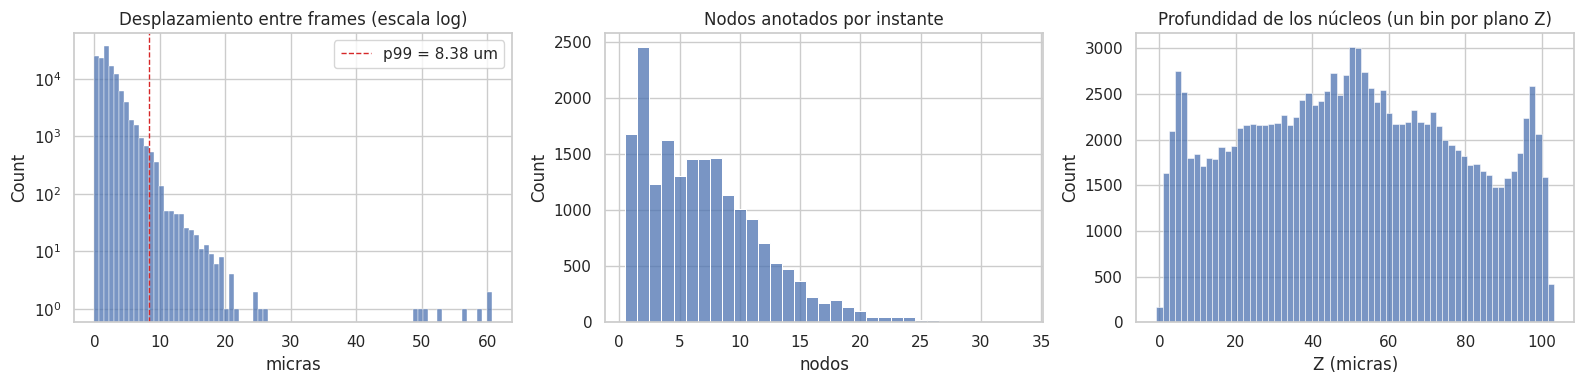

In [44]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

d1 = df_edges.loc[df_edges.dt == 1, "dist_um"]
sns.histplot(d1, bins=80, ax=ax[0])
ax[0].set_yscale("log")
ax[0].axvline(d1.quantile(.99), ls="--", lw=1, color="tab:red", label=f"p99 = {d1.quantile(.99):.2f} um")
ax[0].set_title("Desplazamiento entre frames (escala log)"); ax[0].set_xlabel("micras"); ax[0].legend()

nodos_t = df_nodes.groupby(["sample", "t"]).size().rename("n").reset_index()
sns.histplot(nodos_t["n"], bins=np.arange(.5, nodos_t["n"].max() + 1.5), ax=ax[1])
ax[1].set_title("Nodos anotados por instante"); ax[1].set_xlabel("nodos")

# z es entero en vóxeles: un bin por plano evita el patrón de barras alternadas.
bordes_z = (np.arange(int(df_samples["Z"].max()) + 1) - 0.5) * VOXEL_UM[0]
sns.histplot(df_nodes["z_um"], bins=bordes_z, ax=ax[2])
ax[2].set_title("Profundidad de los núcleos (un bin por plano Z)"); ax[2].set_xlabel("Z (micras)")

plt.tight_layout(); plt.show()

- **Desplazamiento.** La distribución es asimétrica, con cola derecha larga. En escala log se ve que la
  cola más allá de ~10 µm la forman pocas aristas, pero llega hasta 60 µm (ver 5.7).
- **Nodos por instante.** Mediana 6, rango 1 – 33. Frente a miles de células estimadas por volumen,
  esto confirma que la referencia cubre solo una fracción de las células presentes.
- **Profundidad.** Los núcleos anotados cubren de 0 a 102 µm, sin concentrarse en ninguna región. Con
  un bin por plano, la distribución es suave. Hay muy pocos centroides en el primer y el último plano
  y dos acumulaciones cerca de ~5 µm y ~97 µm, posiblemente por núcleos cortados por el borde del
  volumen, cuyo centroide queda justo dentro. No hay evidencia de un sesgo espacial fuerte en las
  anotaciones.

## 5.3 Variables categóricas: frecuencias y proporciones

In [45]:
def tabla_frecuencia(serie, nombre):
    t = pd.concat([serie.value_counts().rename("frecuencia"),
                   (serie.value_counts(normalize=True) * 100).round(2).rename("%")], axis=1)
    print(f"\n--- {nombre} ---")
    display(t)
    return t

tabla_frecuencia(df_samples["embryo_id"], "Muestras por embrión")
tabla_frecuencia(df_nodes["embryo_id"], "Nodos anotados por embrión")
tabla_frecuencia(df_nodes["tipo_temporal"], "Tipo de nodo dentro de la trayectoria")
tabla_frecuencia(df_nodes["out_degree"], "Grado de salida (2 = división)")
tabla_frecuencia(df_nodes["in_degree"], "Grado de entrada")
None


--- Muestras por embrión ---


,frecuencia,%
embryo_id,,
6bba,128,64.32
44b6,71,35.68



--- Nodos anotados por embrión ---


,frecuencia,%
embryo_id,,
6bba,113121,84.85
44b6,20197,15.15



--- Tipo de nodo dentro de la trayectoria ---


,frecuencia,%
tipo_temporal,,
intermedio,124297,93.23
fin,4586,3.44
inicio,4435,3.33



--- Grado de salida (2 = división) ---


,frecuencia,%
out_degree,,
1,128581,96.45
0,4586,3.44
2,151,0.11



--- Grado de entrada ---


,frecuencia,%
in_degree,,
1,128883,96.67
0,4435,3.33


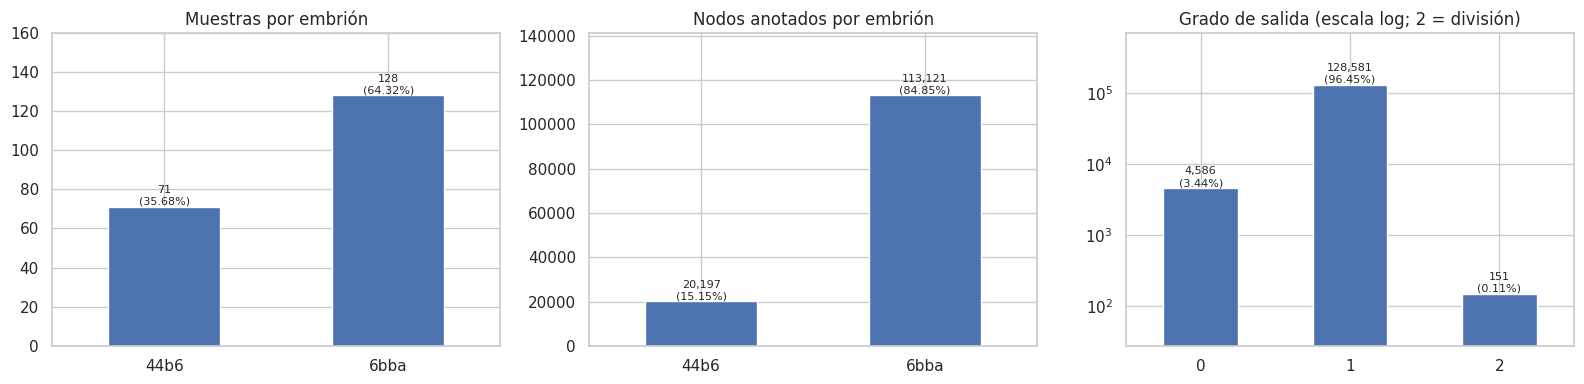

In [46]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

def barras(serie, ax, titulo, logy=False):
    vc = serie.value_counts().sort_index()
    vc.plot.bar(ax=ax, logy=logy, color=sns.color_palette()[0])
    for i, v in enumerate(vc):
        ax.annotate(f"{v:,}\n({v / vc.sum() * 100:.2f}%)", (i, v), ha="center", va="bottom", fontsize=8)
    ax.set_title(titulo); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
    ax.margins(y=.25)

barras(df_samples["embryo_id"], ax[0], "Muestras por embrión")
barras(df_nodes["embryo_id"], ax[1], "Nodos anotados por embrión")
barras(df_nodes["out_degree"], ax[2], "Grado de salida (escala log; 2 = división)", logy=True)
plt.tight_layout(); plt.show()

tipo_temporal,fin,inicio,intermedio
embryo_id,,,
44b6,1.97,1.84,96.2
6bba,3.70,3.59,92.7


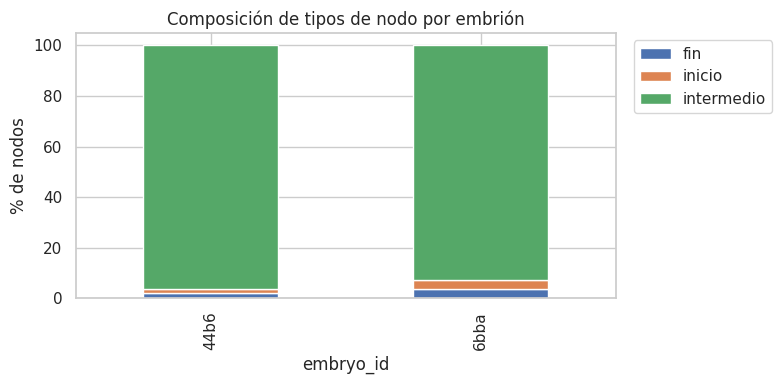

In [47]:
# Tabla cruzada: composición de tipos de nodo por embrión (proporciones por fila)
cruce = pd.crosstab(df_nodes["embryo_id"], df_nodes["tipo_temporal"], normalize="index") * 100
display(cruce.round(2))

cruce.plot(kind="bar", stacked=True, figsize=(8, 4))
plt.ylabel("% de nodos"); plt.title("Composición de tipos de nodo por embrión")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left"); plt.tight_layout(); plt.show()

- **Embriones.** El conjunto está desbalanceado: 6bba aporta el 64.3% de las muestras (128 de 199) y
  el **84.9% de los nodos** anotados. Las métricas agregadas están dominadas por un solo embrión.
- **Estructura del grafo.** Es predominantemente lineal: el 93.2% de los nodos son intermedios. Solo
  151 nodos (0.11%) son divisiones (`out_degree = 2`).
- **Inicio y fin.** Las proporciones de nodos de inicio (3.33%) y fin (3.44%) son parecidas. Eso es
  compatible con trayectorias cortadas por la ventana de anotación, pero la estructura del grafo por
  sí sola no permite descartar eventos biológicos.
- **Composición por embrión.** Es semejante: los intermedios son el 96.2% en 44b6 y el 92.7% en 6bba.
  La forma de los grafos se conserva entre embriones; lo que cambia es la cantidad de anotación.

## 5.4 Esparcidad de la anotación: el hallazgo central

Cada grafo incluye en sus metadatos `estimated_number_of_nodes`, una estimación del número real de
células en el volumen. Dividir los nodos anotados entre esa cifra da la variable más informativa del
análisis, porque cuantifica el supuesto central del conjunto de datos: la **supervisión parcial**.

Muestras menos anotadas:
       sample embryo_id  n_nodos  estimated_number_of_nodes  densidad_anotacion  cobertura_temporal
44b6_18ced818      44b6      100                      78644                0.13                1.00
44b6_cf2536e8      44b6       76                      57565                0.13                0.76
44b6_0b24845f      44b6       51                      32795                0.16                0.40
44b6_e31261b4      44b6      116                      72856                0.16                0.82
44b6_706092f0      44b6      118                      69898                0.17                1.00

Muestras más anotadas:
       sample embryo_id  n_nodos  estimated_number_of_nodes  densidad_anotacion  cobertura_temporal
6bba_2819ca14      6bba      986                       5534               17.82                1.00
6bba_6feeb0b1      6bba     1389                       7518               18.48                1.00
6bba_5f89039d      6bba      904                   

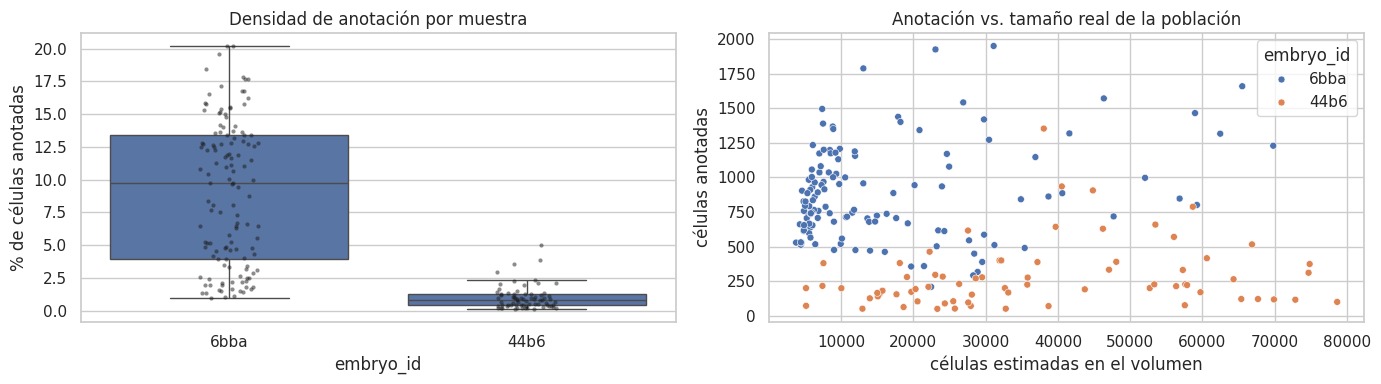

In [48]:
# --- Densidad de anotación: qué fracción de las células está etiquetada ------
df_samples["densidad_anotacion"] = (df_samples["n_nodos"] /
                                    df_samples["estimated_number_of_nodes"] * 100)

cols_d = ["sample", "embryo_id", "n_nodos", "estimated_number_of_nodes",
          "densidad_anotacion", "cobertura_temporal"]
orden_d = df_samples.sort_values("densidad_anotacion")
print("Muestras menos anotadas:")
print(orden_d[cols_d].head(5).round(2).to_string(index=False))
print("\nMuestras más anotadas:")
print(orden_d[cols_d].tail(5).round(2).to_string(index=False))

glob = df_samples.n_nodos.sum() / df_samples.estimated_number_of_nodes.sum() * 100
print(f"\nDensidad global: {glob:.2f}% de las células estimadas están anotadas")
print(f"Rango entre muestras: {df_samples.densidad_anotacion.min():.2f}% – "
      f"{df_samples.densidad_anotacion.max():.2f}% "
      f"(factor {df_samples.densidad_anotacion.max()/df_samples.densidad_anotacion.min():.0f}x)")
est = df_samples["estimated_number_of_nodes"]
print(f"Células estimadas por volumen: {est.min():,} – {est.max():,} (factor {est.max() / est.min():.0f}x)")
print("\nPor embrión:")
print(df_samples.groupby("embryo_id")["densidad_anotacion"].describe()[["count","mean","min","max"]].round(2))

# Con cientos de muestras un barplot por muestra es ilegible: se resume por embrión.
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=df_samples, x="embryo_id", y="densidad_anotacion", ax=ax[0], showfliers=False)
sns.stripplot(data=df_samples, x="embryo_id", y="densidad_anotacion", ax=ax[0],
              color="k", size=3, alpha=.5)
ax[0].set_title("Densidad de anotación por muestra"); ax[0].set_ylabel("% de células anotadas")

sns.scatterplot(data=df_samples, x="estimated_number_of_nodes", y="n_nodos",
                hue="embryo_id", ax=ax[1], s=25)
ax[1].set_xlabel("células estimadas en el volumen"); ax[1].set_ylabel("células anotadas")
ax[1].set_title("Anotación vs. tamaño real de la población")
plt.tight_layout(); plt.show()

- **Densidad global: 2.82%** de las células estimadas están anotadas. Con 30 muestras era 2.05%.
- **Rango entre muestras: 0.13% – 20.21%**, un factor de 159×.
- **Por embrión:** 6bba promedia 8.98% (0.93 – 20.21%) y 44b6 apenas 0.99% (0.13 – 5.02%), una
  diferencia de unas 9 veces.

La cobertura es baja y muy heterogénea. El diagrama de dispersión no muestra una relación positiva
entre células estimadas y anotadas: las muestras con más células estimadas tienden a tener menor
densidad, lo que podría reflejar la dificultad de anotar volúmenes densos.

**Implicación.** El entrenamiento debe distinguir regiones anotadas de no anotadas, y no tratar la
ausencia de etiqueta como fondo. La evaluación tampoco puede contar como falso positivo toda detección
sin pareja en la referencia; la métrica oficial ya incorpora esto.

## 5.5 Análisis bivariado y multivariado: cruces con el tiempo y entre embriones

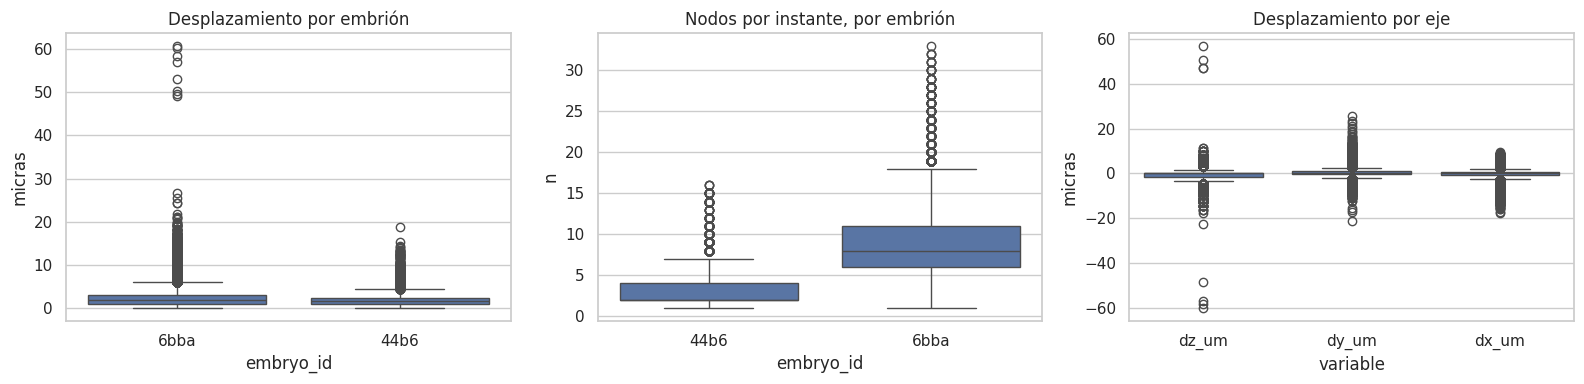

In [49]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=df_edges[df_edges.dt == 1], x="embryo_id", y="dist_um", ax=ax[0])
ax[0].set_title("Desplazamiento por embrión"); ax[0].set_ylabel("micras")

sns.boxplot(data=nodos_t.merge(df_samples[["sample", "embryo_id"]], on="sample"),
            x="embryo_id", y="n", ax=ax[1])
ax[1].set_title("Nodos por instante, por embrión")

sns.boxplot(data=df_edges[df_edges.dt == 1].melt(value_vars=["dz_um", "dy_um", "dx_um"]),
            x="variable", y="value", ax=ax[2])
ax[2].set_title("Desplazamiento por eje"); ax[2].set_ylabel("micras")

plt.tight_layout(); plt.show()

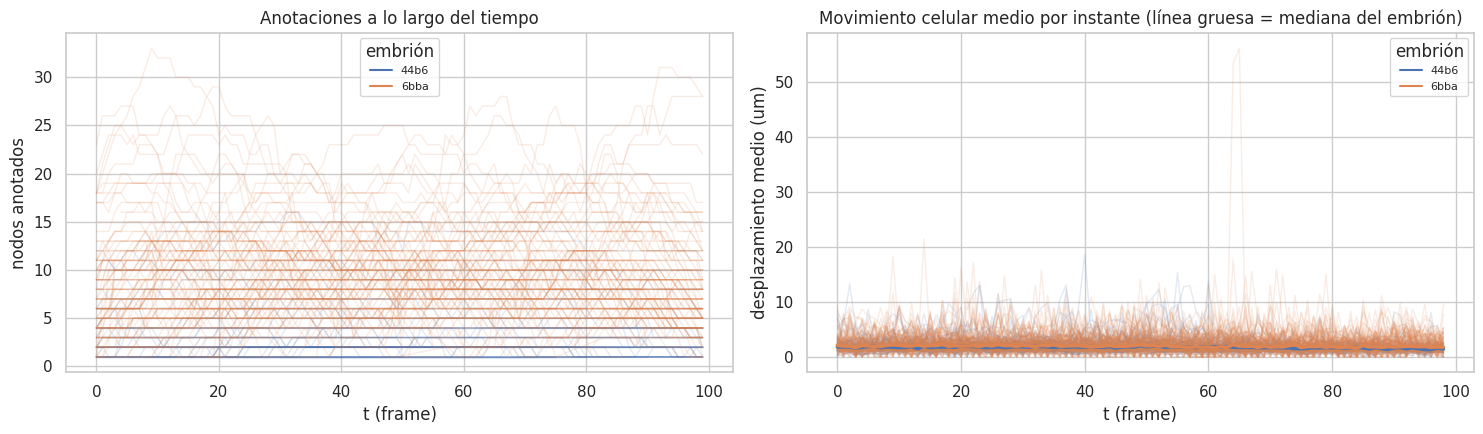

In [50]:
# Una línea por muestra, coloreada por embrión (con cientos de muestras la
# leyenda por muestra deja de ser legible).
embriones = sorted(df_samples["embryo_id"].unique())
COLOR_EMB = dict(zip(embriones, sns.color_palette(n_colors=len(embriones))))
ALPHA_LINEA = max(.15, min(1.0, 15 / len(df_samples)))


def leyenda_embriones(ax):
    from matplotlib.lines import Line2D
    ax.legend(handles=[Line2D([], [], color=c, label=e) for e, c in COLOR_EMB.items()],
              title="embrión", fontsize=8)


fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))

for s, g in nodos_t.groupby("sample"):
    ax[0].plot(g["t"], g["n"], lw=1, alpha=ALPHA_LINEA, color=COLOR_EMB[s.split("_")[0]])
ax[0].set_xlabel("t (frame)"); ax[0].set_ylabel("nodos anotados")
ax[0].set_title("Anotaciones a lo largo del tiempo"); leyenda_embriones(ax[0])

mov = df_edges[df_edges.dt == 1].groupby(["sample", "t_origen"])["dist_um"].mean().reset_index()
for s, g in mov.groupby("sample"):
    ax[1].plot(g["t_origen"], g["dist_um"], lw=1, alpha=ALPHA_LINEA, color=COLOR_EMB[s.split("_")[0]])
# Mediana por embrión encima, para ver la tendencia general
for e, g in mov.assign(embryo_id=mov["sample"].str.split("_").str[0]).groupby("embryo_id"):
    m = g.groupby("t_origen")["dist_um"].median()
    ax[1].plot(m.index, m.values, lw=2.5, color=COLOR_EMB[e])
ax[1].set_xlabel("t (frame)"); ax[1].set_ylabel("desplazamiento medio (um)")
ax[1].set_title("Movimiento celular medio por instante (línea gruesa = mediana del embrión)")
leyenda_embriones(ax[1])

plt.tight_layout(); plt.show()

In [51]:
# --- Comparación entre embriones ---------------------------------------------
# La unidad de comparación es la MUESTRA, no la arista: las aristas de una misma
# trayectoria no son independientes, así que una prueba sobre 128k aristas daría
# significancia artificial.
from scipy.stats import mannwhitneyu

e1 = df_edges[df_edges.dt == 1]
por_muestra = (e1.groupby(["sample", "embryo_id"])["dist_um"].median().rename("desplaz_mediana_um")
               .reset_index().merge(df_samples[["sample", "densidad_anotacion", "nodos_por_t",
                                                "cobertura_temporal"]], on="sample"))

comp = pd.DataFrame({
    "muestras": df_samples.groupby("embryo_id").size(),
    "nodos": df_nodes.groupby("embryo_id").size(),
    "desplaz_mediana_um": e1.groupby("embryo_id")["dist_um"].median(),
    "desplaz_p99_um": e1.groupby("embryo_id")["dist_um"].quantile(.99),
    "nodos_por_t (mediana)": df_samples.groupby("embryo_id")["nodos_por_t"].median(),
    "densidad_media_%": df_samples.groupby("embryo_id")["densidad_anotacion"].mean(),
    "cobertura_temporal_media": df_samples.groupby("embryo_id")["cobertura_temporal"].mean(),
    "cobertura_temporal_min": df_samples.groupby("embryo_id")["cobertura_temporal"].min(),
    "divisiones": df_samples.groupby("embryo_id")["n_divisiones"].sum(),
}).round(3)
display(comp)

emb = sorted(por_muestra["embryo_id"].unique())
if len(emb) == 2:
    print("Prueba de Mann-Whitney entre embriones (unidad = muestra):")
    for var in ["desplaz_mediana_um", "densidad_anotacion", "nodos_por_t"]:
        a = por_muestra.loc[por_muestra.embryo_id == emb[0], var].dropna()
        b = por_muestra.loc[por_muestra.embryo_id == emb[1], var].dropna()
        p = mannwhitneyu(a, b).pvalue
        print(f"  {var:<20} mediana {emb[0]}={a.median():.3f}  {emb[1]}={b.median():.3f}  p = {p:.2e}")

,muestras,nodos,desplaz_mediana_um,desplaz_p99_um,nodos_por_t (mediana),densidad_media_%,cobertura_temporal_media,divisiones
embryo_id,,,,,,,,
44b6,71,20197,1.724,7.199,2.140,0.985,0.90,26
6bba,128,113121,1.817,8.492,8.352,8.978,0.98,125


Prueba de Mann-Whitney entre embriones (unidad = muestra):
  desplaz_mediana_um   mediana 44b6=1.724  6bba=1.817  p = 5.14e-01
  densidad_anotacion   mediana 44b6=0.772  6bba=9.715  p = 9.36e-28
  nodos_por_t          mediana 44b6=2.140  6bba=8.352  p = 6.17e-25


**Lectura de las gráficas.**

- **Nodos por instante.** 44b6 tiene muchos menos nodos por instante que 6bba; es la misma diferencia
  de cobertura que se vio en 5.4.
- **Desplazamiento por eje.** Las dispersiones son comparables entre ejes una vez convertidos a micras.
- **En el tiempo.** El desplazamiento medio por instante se mantiene alrededor de 2 µm, sin tendencia
  temporal. Los picos aislados salen de pocas aristas. El más alto (~55 µm cerca
  de t = 65) es un salto colectivo de una sola muestra, que se analiza en 5.7.b.

**Comparación entre embriones.** En las 199 muestras, el desplazamiento mediano es 1.82 µm en 6bba y
1.72 µm en 44b6, mientras que las densidades medias de anotación son 8.98% y 0.99%. La diferencia
principal entre embriones está en **cuánto se anotó**, no en cómo se mueven las células. La prueba de
Mann-Whitney, con la muestra como unidad, lo confirma:

| Variable | 44b6 | 6bba | p |
|---|---|---|---|
| desplazamiento mediano (µm) | 1.72 | 1.82 | 0.51 |
| densidad de anotación (%) | 0.77 | 9.72 | ≈ 10⁻²⁸ |
| nodos por instante | 2.1 | 8.4 | ≈ 10⁻²⁵ |

Las células de ambos embriones se mueven igual; lo que cambia es cuánto se anotó. El p99 del
desplazamiento también es parecido (7.2 y 8.5 µm), así que un solo radio de búsqueda sirve para ambos.

**Implicación para la validación.** Como prueba y entrenamiento usan embriones distintos, la validación
debe partirse por `embryo_id`. Con solo dos embriones, cualquier estimación de generalización será
frágil, y eso debe declararse.

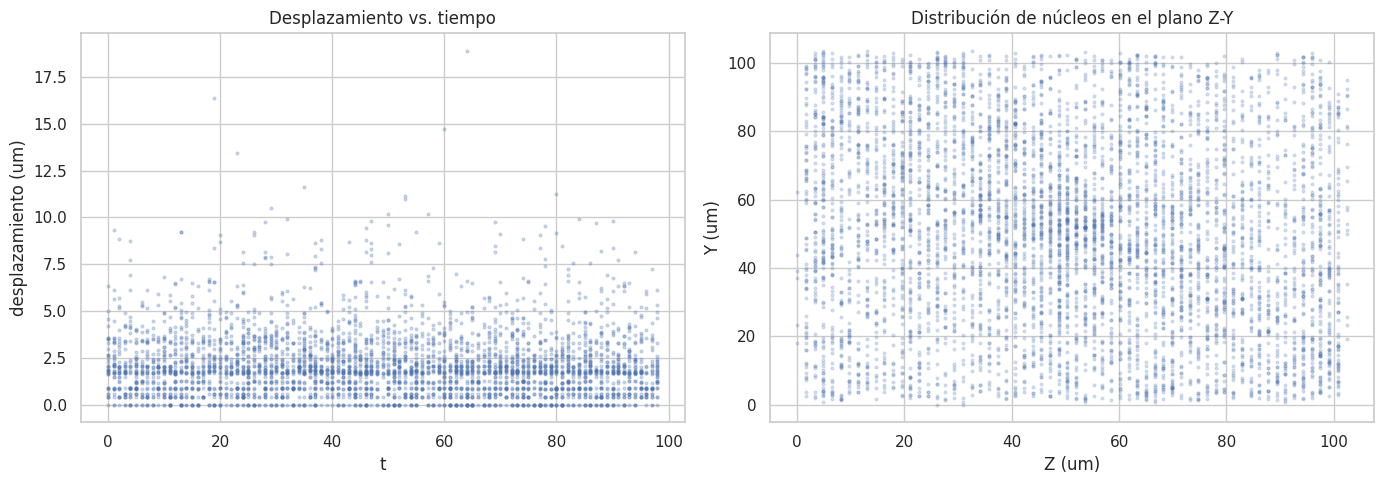

In [52]:
# Subconjunto de aristas consecutivas, con respaldo si el filtro deja poco
E1 = df_edges[df_edges["dt"] == 1]
if len(E1) == 0:
    print(f"AVISO: ninguna arista tiene dt == 1 (dt observados: "
          f"{df_edges['dt'].dropna().unique()[:5]}). Se usan todas las aristas.")
    E1 = df_edges.dropna(subset=["dist_um"])

def submuestra(df, n):
    return df.sample(min(n, len(df)), random_state=0) if len(df) else df

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sub = submuestra(E1, 4000)
ax[0].scatter(sub["t_origen"], sub["dist_um"], s=4, alpha=.25)
ax[0].set_xlabel("t"); ax[0].set_ylabel("desplazamiento (um)")
ax[0].set_title("Desplazamiento vs. tiempo")

nodos_z = submuestra(df_nodes, 6000)
ax[1].scatter(nodos_z["z_um"], nodos_z["y_um"], s=4, alpha=.2)
ax[1].set_xlabel("Z (um)"); ax[1].set_ylabel("Y (um)")
ax[1].set_title("Distribución de núcleos en el plano Z-Y")

plt.tight_layout(); plt.show()

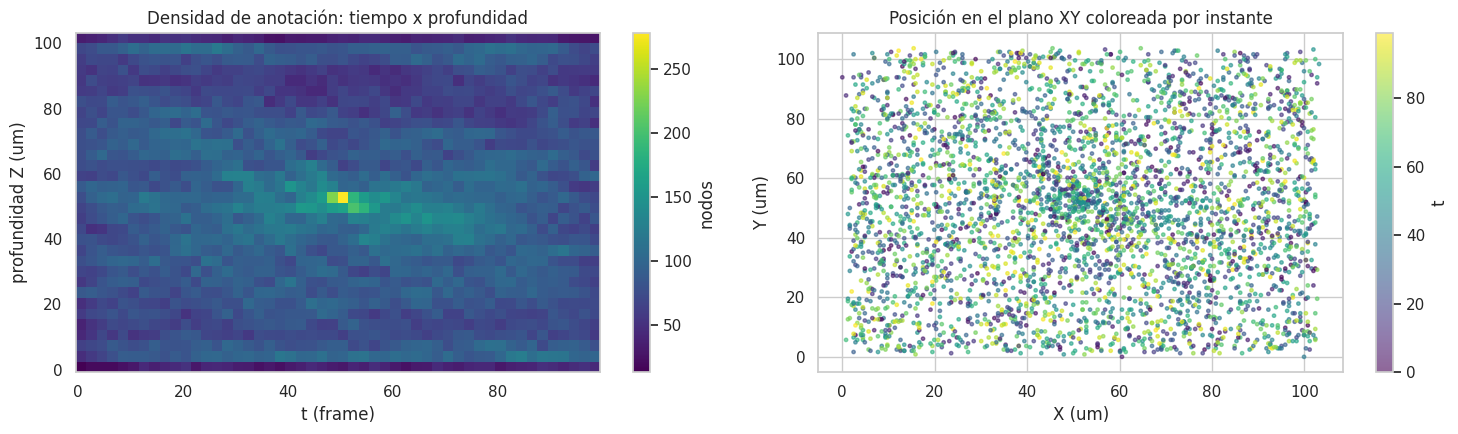

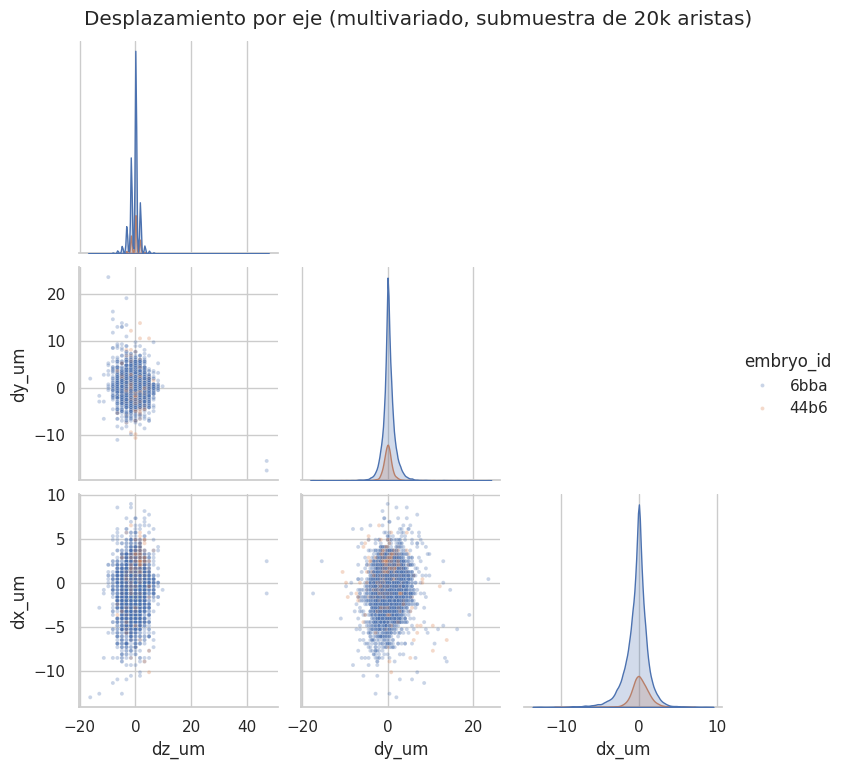

In [53]:
# --- Vistas multivariadas ----------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))

# Bins alineados a los valores discretos: 2 frames x 2 planos Z por celda.
# Con bins arbitrarios (p. ej. 40 x 30) aparecen franjas por aliasing.
bt = np.arange(-.5, df_nodes["t"].max() + 2, 2)
bz = (np.arange(0, int(df_samples["Z"].max()) + 2, 2) - .5) * VOXEL_UM[0]
h = ax[0].hist2d(df_nodes["t"], df_nodes["z_um"], bins=[bt, bz], cmap="viridis")
plt.colorbar(h[3], ax=ax[0], label="nodos")
ax[0].set_xlabel("t (frame)"); ax[0].set_ylabel("profundidad Z (um)")
ax[0].set_title("Densidad de anotación: tiempo x profundidad")

sub = df_nodes.sample(min(4000, len(df_nodes)), random_state=0)
sc = ax[1].scatter(sub["x_um"], sub["y_um"], c=sub["t"], s=6, alpha=.6, cmap="viridis")
plt.colorbar(sc, ax=ax[1], label="t")
ax[1].set_xlabel("X (um)"); ax[1].set_ylabel("Y (um)")
ax[1].set_title("Posición en el plano XY coloreada por instante")
plt.tight_layout(); plt.show()

# Relación conjunta de las tres componentes del desplazamiento
E1 = df_edges[df_edges.dt == 1]
g = sns.pairplot(E1[["dz_um", "dy_um", "dx_um", "embryo_id"]].sample(min(20000, len(E1)), random_state=0),
                 hue="embryo_id", corner=True, plot_kws=dict(s=8, alpha=.3))
g.figure.suptitle("Desplazamiento por eje (multivariado, submuestra de 20k aristas)", y=1.02)
plt.show()

Las anotaciones se reparten de forma bastante uniforme en tiempo × profundidad y en el plano XY. No
hay regiones ni intervalos de tiempo vacíos que sugieran un sesgo de anotación. El *pairplot* muestra
las componentes del desplazamiento centradas en cero; en `dz_um` se ve la cuantización en múltiplos
de 1.625 µm.

## 5.6 Correlaciones y deriva direccional

Se excluye `dt` porque es constante (en la versión anterior aparecía como una fila en blanco).

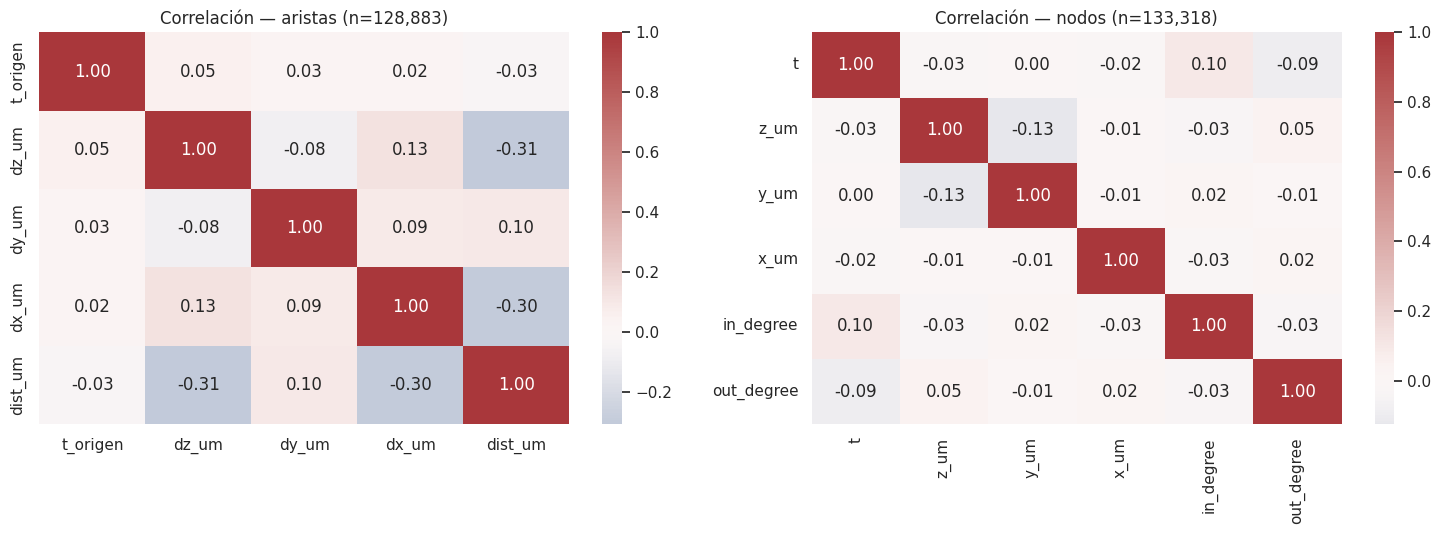

In [54]:
# Correlaciones a nivel arista y nodo (miles de observaciones cada una)
num_edges = df_edges[["t_origen", "dz_um", "dy_um", "dx_um", "dist_um"]]
num_nodes = df_nodes[["t", "z_um", "y_um", "x_um", "in_degree", "out_degree"]]

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(num_edges.corr(), annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax[0])
ax[0].set_title(f"Correlación — aristas (n={len(df_edges):,})")
sns.heatmap(num_nodes.corr(), annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax[1])
ax[1].set_title(f"Correlación — nodos (n={len(df_nodes):,})")
plt.tight_layout(); plt.show()

**Un resultado que hay que revisar.** `dist_um` correlaciona −0.31 con `dz_um` y −0.30 con `dx_um`.
El informe lo atribuía a que la distancia se calcula a partir de esas componentes, pero esa explicación
no alcanza: si el movimiento fuera simétrico (igual de probable hacia + que hacia −), una componente
*con signo* no correlacionaría con la magnitud. Una correlación negativa significa que **los
desplazamientos grandes tienden a ir en dirección negativa** de Z y de X.

Hay dos explicaciones posibles: una deriva real del tejido (en el desarrollo del pez cebra hay
movimientos colectivos, como la epibolia o la convergencia-extensión) o el efecto de unos pocos saltos
extremos (5.7). La celda siguiente las separa:

1. Repite la correlación sin los extremos y con Spearman, que es robusta a valores atípicos.
2. Calcula el desplazamiento medio de cada muestra y comprueba si la dirección es consistente entre
   muestras. La unidad es la muestra, para no tratar como independientes las aristas de una misma
   trayectoria.

Correlación de dist_um con cada componente:
       Pearson (todas)  Pearson (sin extremos)  Spearman (todas)
dz_um           -0.309                  -0.279            -0.279
dy_um            0.099                   0.086             0.064
dx_um           -0.298                  -0.246            -0.192

Signo de los pasos no nulos (proporción):
  dz_um: negativos 0.666 | positivos 0.334
  dy_um: negativos 0.449 | positivos 0.551
  dx_um: negativos 0.565 | positivos 0.435

Desplazamiento medio por muestra (um/frame), media ± IC95% entre muestras:
  44b6 (n=71): dz_um -0.208 ± 0.183 (70% muestras < 0) | dy_um -0.131 ± 0.159 (54% muestras < 0) | dx_um -0.000 ± 0.176 (49% muestras < 0)
  6bba (n=128): dz_um -0.520 ± 0.137 (73% muestras < 0) | dy_um +0.192 ± 0.150 (47% muestras < 0) | dx_um -0.362 ± 0.165 (61% muestras < 0)


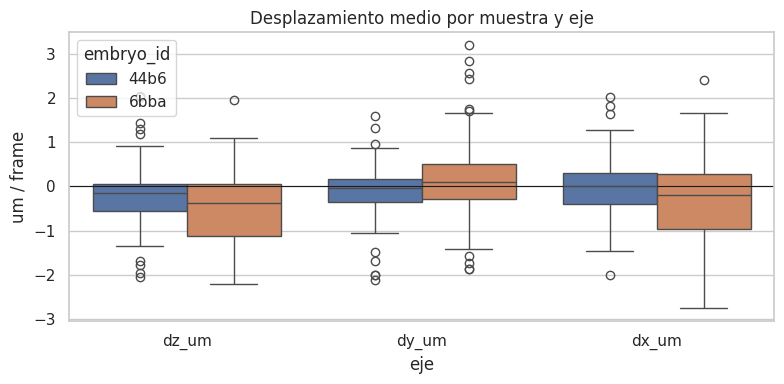

In [55]:
e1 = df_edges[df_edges.dt == 1]
q1, q3 = e1["dist_um"].quantile([.25, .75])
sin_ext = e1[e1["dist_um"] <= q3 + 3 * (q3 - q1)]

print("Correlación de dist_um con cada componente:")
print(pd.DataFrame({
    "Pearson (todas)": e1[["dz_um", "dy_um", "dx_um"]].corrwith(e1["dist_um"]),
    "Pearson (sin extremos)": sin_ext[["dz_um", "dy_um", "dx_um"]].corrwith(sin_ext["dist_um"]),
    "Spearman (todas)": e1[["dz_um", "dy_um", "dx_um"]].corrwith(e1["dist_um"], method="spearman"),
}).round(3))

print("\nSigno de los pasos no nulos (proporción):")
for c in ["dz_um", "dy_um", "dx_um"]:
    nz = e1.loc[e1[c] != 0, c]
    print(f"  {c}: negativos {(nz < 0).mean():.3f} | positivos {(nz > 0).mean():.3f}")

# Deriva por muestra: media del desplazamiento por eje en cada muestra
deriva = e1.groupby(["sample", "embryo_id"])[["dz_um", "dy_um", "dx_um"]].mean().reset_index()
print("\nDesplazamiento medio por muestra (um/frame), media ± IC95% entre muestras:")
for e, g in deriva.groupby("embryo_id"):
    partes = []
    for c in ["dz_um", "dy_um", "dx_um"]:
        m, ic = g[c].mean(), 1.96 * g[c].std(ddof=1) / np.sqrt(len(g))
        partes.append(f"{c} {m:+.3f} ± {ic:.3f} ({(g[c] < 0).mean() * 100:.0f}% muestras < 0)")
    print(f"  {e} (n={len(g)}): " + " | ".join(partes))

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=deriva.melt(id_vars=["sample", "embryo_id"], var_name="eje", value_name="media_um"),
            x="eje", y="media_um", hue="embryo_id", ax=ax)
ax.axhline(0, color="k", lw=.8)
ax.set_title("Desplazamiento medio por muestra y eje"); ax.set_ylabel("um / frame")
plt.tight_layout(); plt.show()

**Resultado: sí hay deriva direccional, y no la explican los extremos.** Esto corrige al informe, que
concluía que no había una deriva marcada (secciones 5.5 y 5.6).

- **La correlación persiste.** Sin los extremos apenas cambia (dz: −0.31 → −0.28; dx: −0.30 → −0.25),
  y con Spearman es similar (−0.28 y −0.19).
- **Los pasos tienen dirección preferente.** El 66.6% de los pasos no nulos en Z son negativos, contra
  33.4% positivos: una proporción de 2:1. En X la proporción es 56.5% / 43.5%, y en Y hay un ligero
  sesgo positivo (55.1%).
- **Es consistente entre muestras.** En 6bba, la deriva es −0.52 ± 0.14 µm/frame en Z (73% de sus
  muestras con media negativa) y −0.36 ± 0.17 en X. En 44b6 es −0.21 ± 0.18 en Z (70% de las
  muestras), sin deriva en X.
- **No es universal.** Cerca del 30% de las muestras va en sentido contrario, y la dispersión entre
  muestras es grande. Eso apunta más a flujos de tejido que cambian según la región observada
  (movimientos morfogenéticos del embrión) que a un desplazamiento uniforme del microscopio. Con estos
  datos no se puede descartar ninguna de las dos causas.

**Implicación.** La magnitud (~0.5 µm/frame) es pequeña frente al radio de búsqueda (8.4 µm), así que
no impide enlazar con un costo simétrico. Pero es sistemática: acumulada sobre un linaje mediano (21
frames) suma ~11 µm. El enlace debería predecir la posición siguiente con el desplazamiento medio local
(por muestra e instante), en lugar de suponer que la célula se queda quieta.

En el nivel nodo, las correlaciones son todas cercanas a cero (|r| ≤ 0.13): la posición, el instante y
el grado no tienen relación lineal relevante.

## 5.7 Valores atípicos

Los desplazamientos extremos son el punto crítico del análisis. Si son errores de anotación, un
algoritmo entrenado con ellos aprende ruido. Si son movimiento real, el algoritmo debe tolerarlos y el
radio de búsqueda no puede recortarse.

In [56]:
e1 = df_edges[df_edges.dt == 1]
q1, q3 = e1["dist_um"].quantile([.25, .75])
lim_sup = q3 + 1.5 * (q3 - q1)
out = e1[e1.dist_um > lim_sup]

print(f"Límite de Tukey: {lim_sup:.2f} um")
print(f"Atípicos: {len(out)} de {len(e1)} ({100*len(out)/len(e1):.2f}%)")
print(f"Máximo observado: {e1.dist_um.max():.2f} um")
print("\nAtípicos por embrión (%):")
print((out.groupby("embryo_id").size() / e1.groupby("embryo_id").size() * 100).round(2).to_string())
print("\nAtípicos por tipo de origen: divisiones vs. no divisiones")
print(pd.crosstab(e1.out_degree_origen >= 2, e1.dist_um > lim_sup, normalize="index").round(3))

Límite de Tukey: 5.45 um
Atípicos: 6060 de 128883 (4.70%)
Máximo observado: 60.76 um

Atípicos por embrión (%):
embryo_id
44b6    2.12
6bba    5.17

Atípicos por tipo de origen: divisiones vs. no divisiones
dist_um            False  True 
out_degree_origen              
False              0.954  0.046
True               0.457  0.543


Con 199 muestras, el 4.70% de las aristas supera el límite de Tukey (5.45 µm). La asociación con las
divisiones se fortalece: **el 54.3% de las aristas que salen de una división son atípicas**, frente al
4.6% de las aristas normales. Las células hijas se separan del centro de la madre, así que estos
atípicos son biológicos.

Pero el máximo pasó de 17.97 a **60.76 µm** (≈ 37 planos Z en un solo instante, más de 7 veces el p99).
Para separar movimiento real de errores, se examina la **trayectoria** alrededor de cada arista
extrema (más allá de q3 + 3·RIC) y se clasifica:

| Categoría | Criterio | Interpretación |
|---|---|---|
| sale de división | el nodo de origen se divide | movimiento biológico esperado |
| ida y vuelta | a → b es extremo, pero el siguiente nodo c vuelve cerca de a (se marcan las dos aristas, ida y regreso) | casi seguro un error de anotación: un centroide mal colocado en un solo instante |
| salto sostenido | la trayectoria continúa desde la nueva posición | puede ser movimiento real o un cambio de identidad entre dos células |
| sin continuación | b no tiene sucesor | no se puede determinar |

Límite extremo (q3 + 3·RIC): 8.18 um -> 1,502 aristas (1.17%) en 139 muestras
Eje dominante: {'z': 601, 'x': 503, 'y': 398}

Clasificación de las aristas extremas:
                  aristas     %
categoria                      
salto sostenido      1323  88.1
ida y vuelta           64   4.3
sale de división       59   3.9
sin continuación       56   3.7

Por categoría y embrión:
embryo_id         44b6  6bba
categoria                   
ida y vuelta        20    44
sale de división     5    54
salto sostenido    107  1216
sin continuación     1    55

Las 10 aristas más largas:


,sample,t_origen,dz_um,dy_um,dx_um,dist_um,dist_a_c,categoria
103917,6bba_f20478e9,64.0,56.88,-21.12,3.25,60.76,23.91,salto sostenido
104162,6bba_f20478e9,65.0,-60.12,-2.03,-1.22,60.17,60.26,salto sostenido
104164,6bba_f20478e9,65.0,-58.50,-2.03,0.41,58.54,58.61,salto sostenido
104163,6bba_f20478e9,65.0,-56.88,-2.44,0.81,56.93,57.00,salto sostenido
103918,6bba_f20478e9,64.0,50.38,-16.25,-2.44,52.99,21.04,salto sostenido
104174,6bba_f20478e9,64.0,47.12,-17.47,-1.22,50.27,22.59,salto sostenido
104230,6bba_f20478e9,64.0,47.12,-15.44,2.44,49.65,22.62,salto sostenido
104229,6bba_f20478e9,65.0,-48.75,-6.50,2.84,49.26,49.57,salto sostenido
95800,6bba_e5e44988,14.0,-6.50,25.59,-2.84,26.56,30.88,salto sostenido
95798,6bba_e5e44988,14.0,-9.75,23.56,0.41,25.50,28.39,salto sostenido



Marcadas como posible error: 64 aristas
      todas  sin posible_error
0.50   1.82               1.82
0.95   5.34               5.30
0.99   8.38               8.38
1.00  60.76              60.76


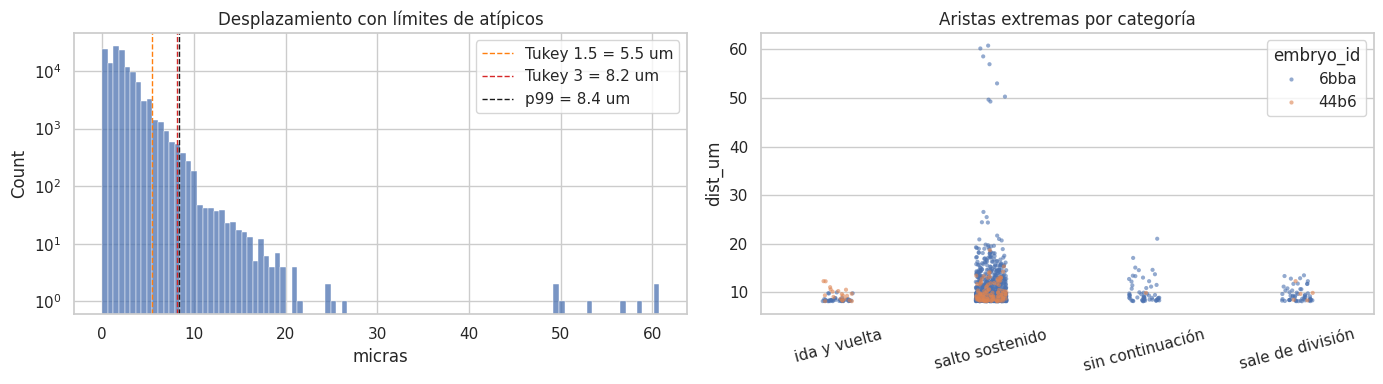

In [57]:
# --- Atípicos extremos: ¿movimiento real o error de anotación? ---------------
e1 = df_edges[df_edges.dt == 1].copy()
q1, q3 = e1["dist_um"].quantile([.25, .75])
lim_tukey, lim_ext = q3 + 1.5 * (q3 - q1), q3 + 3 * (q3 - q1)
ext = e1[e1["dist_um"] > lim_ext].copy()
print(f"Límite extremo (q3 + 3·RIC): {lim_ext:.2f} um -> {len(ext):,} aristas "
      f"({100 * len(ext) / len(e1):.2f}%) en {ext['sample'].nunique()} muestras")

# Eje dominante del salto
ejes = ext[["dz_um", "dy_um", "dx_um"]].abs()
print("Eje dominante:", ejes.idxmax(axis=1).str[1].value_counts().to_dict())

# Arista siguiente: b -> c, encadenando por dst_id == src_id dentro de la muestra
sig = e1[["sample", "src_id", "z0_um", "y0_um", "x0_um", "dz_um", "dy_um", "dx_um"]]
m = ext.reset_index().merge(sig, left_on=["sample", "dst_id"], right_on=["sample", "src_id"],
                            how="left", suffixes=("", "_sig"))
pos_a = m[["z0_um", "y0_um", "x0_um"]].to_numpy()
pos_c = (m[["z0_um_sig", "y0_um_sig", "x0_um_sig"]].to_numpy()
         + m[["dz_um_sig", "dy_um_sig", "dx_um_sig"]].to_numpy())
m["dist_a_c"] = np.linalg.norm(pos_c - pos_a, axis=1)
# Si b se divide hay dos sucesores: basta con que uno regrese
m = m.groupby("index").agg(dist_a_c=("dist_a_c", "min"), tiene_sig=("src_id_sig", lambda s: s.notna().any()))
ext = ext.join(m)
ext["tiene_sig"] = ext["tiene_sig"].fillna(False).astype(bool)

ext["categoria"] = np.select(
    [ext["out_degree_origen"] >= 2,
     ext["tiene_sig"] & (ext["dist_a_c"] <= lim_tukey),
     ~ext["tiene_sig"]],
    ["sale de división", "ida y vuelta", "sin continuación"], default="salto sostenido")
# Un centroide mal puesto en un instante produce DOS aristas extremas: la ida (a -> b)
# y el regreso (b -> c). El regreso parte del nodo destino de una 'ida y vuelta'.
idas = set(zip(ext.loc[ext["categoria"] == "ida y vuelta", "sample"],
               ext.loc[ext["categoria"] == "ida y vuelta", "dst_id"]))
es_regreso = np.array([(s, i) in idas for s, i in zip(ext["sample"], ext["src_id"])], dtype=bool)
ext.loc[es_regreso & (ext["categoria"] != "sale de división"), "categoria"] = "ida y vuelta"

print("\nClasificación de las aristas extremas:")
print(pd.concat([ext["categoria"].value_counts().rename("aristas"),
                 (ext["categoria"].value_counts(normalize=True) * 100).round(1).rename("%")], axis=1))
print("\nPor categoría y embrión:")
print(pd.crosstab(ext["categoria"], ext["embryo_id"]))

print("\nLas 10 aristas más largas:")
display(ext.sort_values("dist_um", ascending=False)
        [["sample", "t_origen", "dz_um", "dy_um", "dx_um", "dist_um", "dist_a_c", "categoria"]]
        .head(10).round(2))

# Decisión: las 'ida y vuelta' se marcan como posible error de anotación
df_edges["posible_error"] = False
df_edges.loc[ext.index[ext["categoria"] == "ida y vuelta"], "posible_error"] = True

e1 = df_edges[df_edges.dt == 1]
limpio = e1[~e1["posible_error"]]["dist_um"]
print(f"\nMarcadas como posible error: {int(df_edges['posible_error'].sum()):,} aristas")
print(pd.DataFrame({"todas": e1["dist_um"].quantile([.5, .95, .99, 1]),
                    "sin posible_error": limpio.quantile([.5, .95, .99, 1])}).round(2))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(e1["dist_um"], bins=100, ax=ax[0])
ax[0].set_yscale("log")
for v, nombre, c in [(lim_tukey, "Tukey 1.5", "tab:orange"), (lim_ext, "Tukey 3", "tab:red"),
                     (e1["dist_um"].quantile(.99), "p99", "k")]:
    ax[0].axvline(v, ls="--", lw=1, color=c, label=f"{nombre} = {v:.1f} um")
ax[0].legend(); ax[0].set_title("Desplazamiento con límites de atípicos"); ax[0].set_xlabel("micras")
sns.stripplot(data=ext, x="categoria", y="dist_um", hue="embryo_id", ax=ax[1], size=3, alpha=.6)
ax[1].set_title("Aristas extremas por categoría"); ax[1].set_xlabel(""); ax[1].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

**Resultado de la clasificación.**

- **El límite extremo cayó en la cola normal.** q3 + 3·RIC = 8.18 µm, prácticamente el p99 (8.38 µm).
  Por eso las 1,502 aristas "extremas" (1.17%, en 139 muestras) son sobre todo la cola real del
  movimiento: el 88% son saltos sostenidos, con el eje dominante repartido entre Z (601), X (503) e
  Y (398).
- **Los errores puntuales son despreciables.** Solo 64 aristas (0.05%) son de ida y vuelta, y quitarlas
  no cambia la mediana, el p99 ni el máximo.
- **59 aristas extremas salen de divisiones**, coherente con lo anterior.
- **La cola tiene un hueco.** Llega de forma continua hasta ~26 µm, se interrumpe, y luego aparecen 8
  aristas entre 49 y 61 µm. **Todas son de `6bba_f20478e9` en t = 64 → 65**: muchas células saltan
  juntas ≈ +50 µm en Z y −17 µm en Y, y regresan en Z en el instante siguiente. Un movimiento colectivo
  de esa magnitud no es biológico.
  - El clasificador las etiquetó como "salto sostenido" porque el desplazamiento en Y no regresa. Es una
    limitación del método: evalúa aristas sueltas y no detecta eventos que afectan a todo un instante.
    Eso se analiza en 5.7.b.

**Decisión sobre los atípicos.**

1. **Atípicos moderados** (Tukey 1.5): se conservan. Se concentran en divisiones y forman parte del
   movimiento real que el algoritmo debe tolerar.
2. **Extremos de tipo "ida y vuelta"**: se marcan como `posible_error`. Se **excluyen al estimar
   parámetros** (radio de búsqueda, distribución del movimiento), pero **no se eliminan de la
   referencia**, porque la métrica oficial se calcula contra ella tal como está.
3. **Saltos sostenidos y sin continuación**: se conservan y se reportan. Son mayoritariamente la cola
   real del movimiento.
4. **Saltos colectivos a nivel de instante**: se tratan en 5.7.b.

### 5.7.b Saltos colectivos a nivel de instante

Si todas las células de un instante se desplazan juntas, la causa no es biológica. Hay dos
posibilidades, con consecuencias distintas:

| | La imagen también se movió | Solo se movió la anotación |
|---|---|---|
| Causa | desplazamiento del campo durante la adquisición | desfase en la anotación de ese instante |
| La referencia | es correcta | tiene un error |
| Implicación | el tracker debe **registrar** (alinear) los instantes antes de enlazar | excluir esas aristas al estimar parámetros |

Para distinguirlas:

1. Se detectan los instantes donde la **mediana** del desplazamiento de todas sus células (con al menos
   3 aristas) supera el límite de Tukey. La mediana evita que una sola célula rápida dispare la alarma.
2. En cada uno se mide cuánto se movió la **imagen completa** entre t y t+1 con correlación de fase 3D,
   y se compara con el salto de la anotación. Como control se incluyen instantes normales al azar.
3. Se inspecciona visualmente el evento más grande, en vistas XY y XZ.

In [ ]:
# --- 5.7.b Detección de saltos colectivos y comparación con la imagen --------
MIN_ARISTAS_INSTANTE = 3     # con menos aristas, la "mediana del instante" es una sola célula
MAX_EVENTOS = 15             # eventos a contrastar con la imagen (cada uno lee 2 volúmenes)

e1 = df_edges[df_edges.dt == 1]
inst = (e1.groupby(["sample", "embryo_id", "t_origen"])
          .agg(n=("dist_um", "size"), dz=("dz_um", "median"), dy=("dy_um", "median"),
               dx=("dx_um", "median"), frac_atipicas=("dist_um", lambda d: (d > lim_tukey).mean()))
          .reset_index())
inst["salto_um"] = np.linalg.norm(inst[["dz", "dy", "dx"]], axis=1)
saltos = (inst[(inst["n"] >= MIN_ARISTAS_INSTANTE) & (inst["salto_um"] > lim_tukey)]
          .sort_values("salto_um", ascending=False))
print(f"Instantes evaluados: {len(inst):,} | con salto colectivo (mediana > {lim_tukey:.2f} um): "
      f"{len(saltos)} en {saltos['sample'].nunique()} muestras")


def desplazamiento_global(v0, v1):
    """Desplazamiento (z, y, x) en vóxeles del contenido de v0 a v1, por correlación de fase 3D."""
    a = v0.astype(np.float32) - v0.mean()
    b = v1.astype(np.float32) - v1.mean()
    F = np.fft.fftn(b) * np.conj(np.fft.fftn(a))
    r = np.fft.ifftn(F / (np.abs(F) + 1e-9)).real
    pico = np.array(np.unravel_index(np.argmax(r), r.shape))
    forma = np.array(r.shape)
    pico[pico > forma // 2] -= forma[pico > forma // 2]     # desplazamientos negativos
    return pico


def salto_imagen(sample, t):
    arr = zarr.open(str(TRAIN_DIR / f"{sample}.zarr" / "0"), mode="r")
    return desplazamiento_global(np.asarray(arr[int(t)]), np.asarray(arr[int(t) + 1])) * VOXEL_UM


# Control: instantes sin movimiento colectivo, para ver cuánto "se mueve" la imagen normalmente
normales = inst[(inst["n"] >= MIN_ARISTAS_INSTANTE) & (inst["salto_um"] < 1)]
control = normales.sample(min(5, len(normales)), random_state=0)

filas = []
for tipo, df in [("salto", saltos.head(MAX_EVENTOS)), ("control", control)]:
    for _, r in tqdm(list(df.iterrows()), desc=f"Correlación de fase ({tipo})"):
        img = salto_imagen(r["sample"], r["t_origen"])
        filas.append({"tipo": tipo, "sample": r["sample"], "t": int(r["t_origen"]), "aristas": int(r["n"]),
                      "anot_dz": r["dz"], "anot_dy": r["dy"], "anot_dx": r["dx"],
                      "img_dz": img[0], "img_dy": img[1], "img_dx": img[2]})
comp_inst = pd.DataFrame(filas)
anot = comp_inst[["anot_dz", "anot_dy", "anot_dx"]].to_numpy()
imag = comp_inst[["img_dz", "img_dy", "img_dx"]].to_numpy()
comp_inst["salto_anot_um"] = np.linalg.norm(anot, axis=1)
comp_inst["salto_img_um"] = np.linalg.norm(imag, axis=1)
comp_inst["diferencia_um"] = np.linalg.norm(anot - imag, axis=1)
comp_inst["veredicto"] = np.select(
    [comp_inst["tipo"] == "control",
     comp_inst["diferencia_um"] <= lim_tukey,
     comp_inst["salto_img_um"] <= lim_tukey],
    ["—", "la imagen también se movió", "solo se movió la anotación"], default="no concluyente")
display(comp_inst.drop(columns=["anot_dz", "anot_dy", "anot_dx", "img_dz", "img_dy", "img_dx"]).round(2))
print("Detalle por eje (um):")
display(comp_inst[["sample", "t", "anot_dz", "img_dz", "anot_dy", "img_dy", "anot_dx", "img_dx"]].round(2))

# Se marcan las aristas de esos instantes; se excluyen al estimar parámetros, igual que posible_error
clave = pd.MultiIndex.from_frame(saltos[["sample", "t_origen"]])
df_edges["salto_instante"] = pd.MultiIndex.from_frame(df_edges[["sample", "t_origen"]]).isin(clave)
e1 = df_edges[df_edges.dt == 1]
excl = e1["posible_error"] | e1["salto_instante"]
print(f"\nAristas en instantes con salto colectivo: {int(e1['salto_instante'].sum()):,}")
print(pd.DataFrame({"todas": e1["dist_um"].quantile([.5, .95, .99, 1]),
                    "sin posible_error ni salto_instante": e1.loc[~excl, "dist_um"].quantile([.5, .95, .99, 1])})
      .round(2))

In [ ]:
# --- Inspección visual del salto colectivo más grande ------------------------
if len(saltos):
    ev = saltos.iloc[0]
    s, t0 = ev["sample"], int(ev["t_origen"])
    arr = zarr.open(str(TRAIN_DIR / f"{s}.zarr" / "0"), mode="r")
    ts = [t for t in (t0 - 1, t0, t0 + 1, t0 + 2) if 0 <= t < arr.shape[0]]

    fig, ax = plt.subplots(2, len(ts), figsize=(4.2 * len(ts), 8.5))
    for j, t in enumerate(ts):
        v = np.asarray(arr[t])
        lo, hi = np.percentile(v, [1, 99.5])
        n = df_nodes[(df_nodes["sample"] == s) & (df_nodes["t"] == t)]
        ax[0, j].imshow(v.max(axis=0), cmap="gray", vmin=lo, vmax=hi)
        ax[0, j].scatter(n["x"], n["y"], s=30, facecolor="none", edgecolor="red", lw=.8)
        ax[0, j].set_title(f"t = {t} · vista XY"); ax[0, j].axis("off")
        # Vista lateral: proyección sobre Y; cada fila es un plano Z (4x más alto que un píxel en X)
        ax[1, j].imshow(v.max(axis=1), cmap="gray", vmin=lo, vmax=hi, aspect=VOXEL_UM[0] / VOXEL_UM[2])
        ax[1, j].scatter(n["x"], n["z"], s=30, facecolor="none", edgecolor="red", lw=.8)
        ax[1, j].set_title(f"t = {t} · vista XZ (Z hacia abajo)"); ax[1, j].axis("off")
    fig.suptitle(f"{s}: salto colectivo t = {t0} → {t0 + 1} | anotación dz={ev['dz']:+.1f}, "
                 f"dy={ev['dy']:+.1f}, dx={ev['dx']:+.1f} um", y=1.0)
    plt.tight_layout(); plt.show()

**Cómo leer el resultado.** Si los núcleos de la imagen se desplazan junto con los círculos rojos y la
correlación de fase da un salto parecido al de la anotación, la referencia es correcta y lo que hay
que corregir es la adquisición, registrando los instantes antes de enlazar. Si la imagen se queda
quieta y solo saltan los círculos, es un error de anotación.

> ⏳ **Interpretación pendiente**: completar con los resultados de la corrida en Kaggle.

## 5.8 Eventos de división celular

Divisiones: 151 de 133318 nodos (0.113%)

Por embrión:
           muestras   nodos  divisiones  muestras_con_division  tasa_division
embryo_id                                                                    
44b6             71   20197          26                     21         0.0013
6bba            128  113121         125                     66         0.0011


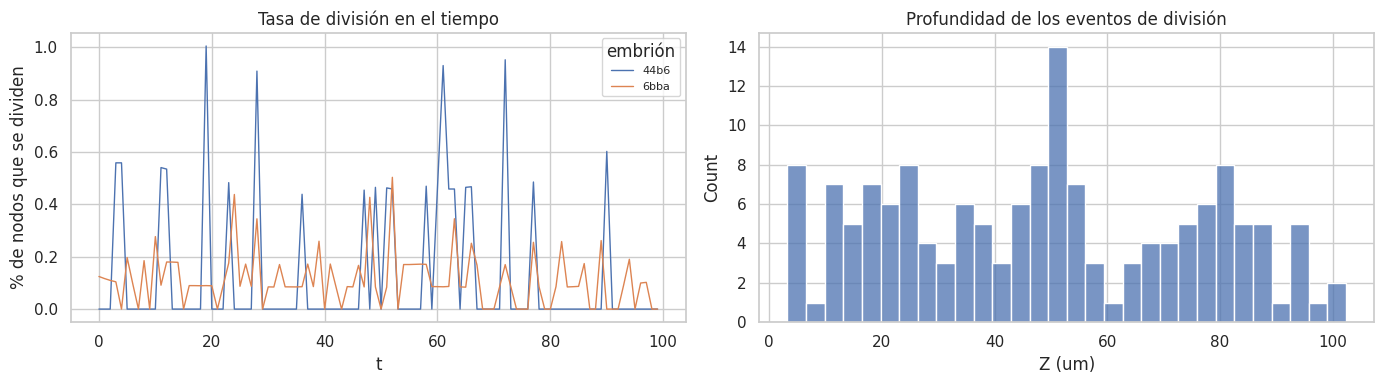

In [58]:
div = df_nodes[df_nodes.es_division]
print(f"Divisiones: {len(div)} de {len(df_nodes)} nodos ({100*len(div)/len(df_nodes):.3f}%)")
print("\nPor embrión:")
print(df_samples.groupby("embryo_id").agg(muestras=("sample", "size"),
                                          nodos=("n_nodos", "sum"),
                                          divisiones=("n_divisiones", "sum"),
                                          muestras_con_division=("n_divisiones", lambda x: (x > 0).sum()))
      .assign(tasa_division=lambda d: d.divisiones / d.nodos).round(4).to_string())

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
# Tasa agregada por instante y embrión: por muestra hay tan pocas divisiones que
# la curva individual es casi siempre 0.
tasa = (df_nodes.groupby(["embryo_id", "t"])["es_division"].mean() * 100).reset_index()
for e, g in tasa.groupby("embryo_id"):
    ax[0].plot(g["t"], g["es_division"], lw=1, color=COLOR_EMB[e], label=e)
ax[0].set_xlabel("t"); ax[0].set_ylabel("% de nodos que se dividen")
ax[0].set_title("Tasa de división en el tiempo"); ax[0].legend(title="embrión", fontsize=8)

if len(div):
    sns.histplot(div["z_um"], bins=30, ax=ax[1])
    ax[1].set_title("Profundidad de los eventos de división"); ax[1].set_xlabel("Z (um)")
plt.tight_layout(); plt.show()

- **151 divisiones en 133,318 nodos = 0.113%**, un desbalance de aproximadamente 1:882.
- Aparecen en **87 de las 199 muestras** (66 de 6bba y 21 de 44b6). Con 30 muestras eran 20 eventos
  en 12 muestras.
- La tasa por nodo es parecida entre embriones: 0.13% en 44b6 y 0.11% en 6bba. A diferencia de la
  densidad de anotación, la frecuencia de división no distingue a los embriones.
- La curva de 44b6 es más irregular porque tiene menos nodos por instante: una sola división es un
  porcentaje mayor.
- Las divisiones ocurren en todo el rango de profundidad, sin concentrarse en la superficie.

Con este desbalance, una exactitud global alta se puede obtener sin detectar ninguna división, así que
esa métrica no sirve por sí sola. El modelado deberá incorporar ponderación de clases o sobremuestreo
de instantes con mitosis, y reportar métricas propias de la clase minoritaria (la competencia evalúa
las divisiones con un Jaccard aparte).

## 5.9 Longitud de los linajes

Linajes: 4435


,count,mean,std,min,25%,50%,75%,max
n_nodos,4435.0,30.06,25.54,2.0,12.0,21.0,39.0,187.0
duracion,4435.0,29.52,24.26,2.0,12.0,21.0,38.5,100.0
n_divisiones,4435.0,0.03,0.18,0.0,0.0,0.0,0.0,1.0


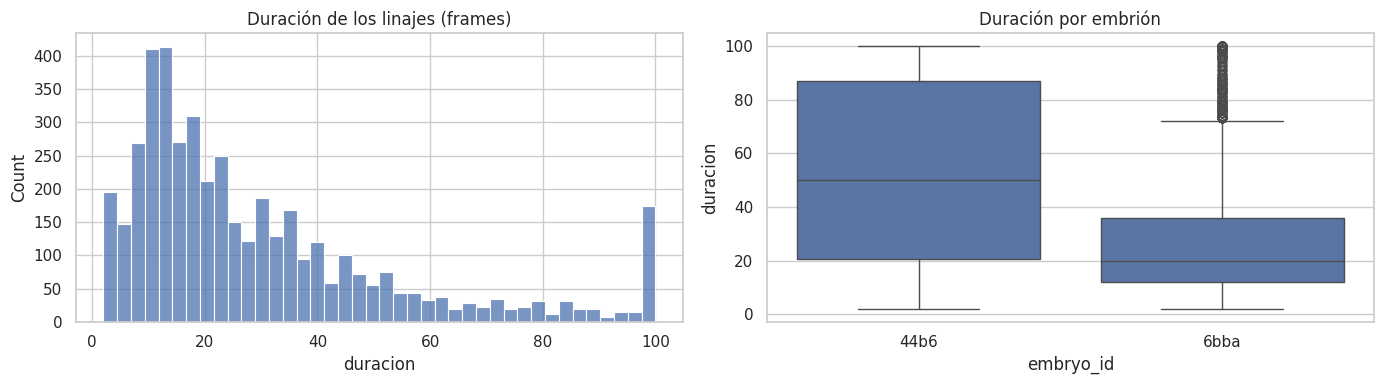

In [59]:
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

filas = []
for s, g in df_nodes.groupby("sample"):
    g = g.reset_index(drop=True)
    pos = {int(v): i for i, v in enumerate(g.node_id)}
    _, ids, _, edges = read_geff(s)
    src = np.array([pos[int(a)] for a, b in edges if int(a) in pos and int(b) in pos], int)
    dst = np.array([pos[int(b)] for a, b in edges if int(a) in pos and int(b) in pos], int)
    m = coo_matrix((np.ones(len(src)), (src, dst)), shape=(len(g), len(g)))
    n_comp, etiqueta = connected_components(m, directed=False)
    g["linaje"] = etiqueta
    filas.append(g.groupby("linaje").agg(sample=("sample", "first"),
                                         embryo_id=("embryo_id", "first"),
                                         n_nodos=("t", "size"),
                                         duracion=("t", lambda x: x.max() - x.min() + 1),
                                         n_divisiones=("es_division", "sum")).reset_index())

df_linajes = pd.concat(filas, ignore_index=True)
print(f"Linajes: {len(df_linajes)}")
display(df_linajes[["n_nodos", "duracion", "n_divisiones"]].describe().T.round(2))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_linajes["duracion"], bins=40, ax=ax[0])
ax[0].set_title("Duración de los linajes (frames)")
sns.boxplot(data=df_linajes, x="embryo_id", y="duracion", ax=ax[1])
ax[1].set_title("Duración por embrión")
plt.tight_layout(); plt.show()

Se identificaron **4,435 linajes** como componentes conexas. Coincide exactamente con el número de
nodos de inicio: cada linaje tiene una sola raíz, lo que confirma que los grafos están bien
construidos.

- La duración tiene mediana 21 frames (media 29.5, desviación 24.3), con un pico en 100 frames: las
  trayectorias que cubren todo el video.
- `n_nodos` llega a 187 aunque la duración máxima es 100. No es un error: después de una división, las
  dos ramas aportan nodos en el mismo instante.
- Ningún linaje contiene más de una división.

**Implicación.** Un algoritmo que aproveche contexto temporal largo tendrá secuencias de 2 a 100
frames y no debe suponer que un linaje corto corresponde a una célula que murió: puede ser solo el
límite de la anotación.

## 5.10 Inspección visual de la imagen

Hasta aquí todo el análisis salió de los grafos. La primera parte reproduce la inspección del informe
(un instante de una muestra) para validar el sistema de coordenadas. La segunda la **extiende a una
submuestra de volúmenes de ambos embriones**, que era una de las limitaciones declaradas en el informe.

In [60]:
# --- Selección de la muestra, el instante y el nivel de pirámide -------------
VIS_SAMPLE = df_samples.sort_values("n_nodos", ascending=False).iloc[0]["sample"]
VIS_T = int(df_nodes[df_nodes["sample"] == VIS_SAMPLE]["t"].value_counts().idxmax())

niveles = image_levels(VIS_SAMPLE)
assert niveles, "No se encontró metadata de imagen para esta muestra."
ndim = len(niveles[sorted(niveles)[0]]["shape"])
if ndim != 4:
    print(f"AVISO: el arreglo tiene {ndim} dimensiones, no 4 (T,Z,Y,X).")
itemsize = np.dtype(niveles["0"]["dtype"]).itemsize if "0" in niveles else 2

info = {}
for name, m in niveles.items():
    mb = np.prod(m["shape"][1:]) * itemsize / 1e6
    info[name] = mb
print("Tamaño de un instante por nivel (MB, sin comprimir):")
for k, v in sorted(info.items()):
    print(f"  nivel {k}: {niveles[k]['shape']} -> {v:.1f} MB")

candidatos = {k: v for k, v in info.items() if v <= IMAGE_BUDGET_MB}
VIS_LEVEL = max(candidatos, key=lambda k: info[k]) if candidatos else min(info, key=lambda k: info[k])
meta = niveles[VIS_LEVEL]

# Si ni el nivel más pequeño cabe en memoria, se recorta una ventana centrada en Y/X.
crop_y = crop_x = None
if info[VIS_LEVEL] > IMAGE_BUDGET_MB:
    shape = meta["shape"]
    f = np.sqrt(IMAGE_BUDGET_MB / info[VIS_LEVEL])
    hy, hx = int(shape[2] * f) // 2, int(shape[3] * f) // 2
    crop_y = (shape[2] // 2 - hy, shape[2] // 2 + hy)
    crop_x = (shape[3] // 2 - hx, shape[3] // 2 + hx)
    print(f"El nivel excede el presupuesto: se recorta Y{crop_y} X{crop_x}")

print(f"\nMuestra: {VIS_SAMPLE} | instante t={VIS_T} | nivel elegido: {VIS_LEVEL} "
      f"({info[VIS_LEVEL]:.1f} MB, shape {meta['shape']})")

Tamaño de un instante por nivel (MB, sin comprimir):
  nivel 0: (100, 64, 256, 256) -> 8.4 MB

Muestra: 6bba_09961292 | instante t=9 | nivel elegido: 0 (8.4 MB, shape (100, 64, 256, 256))


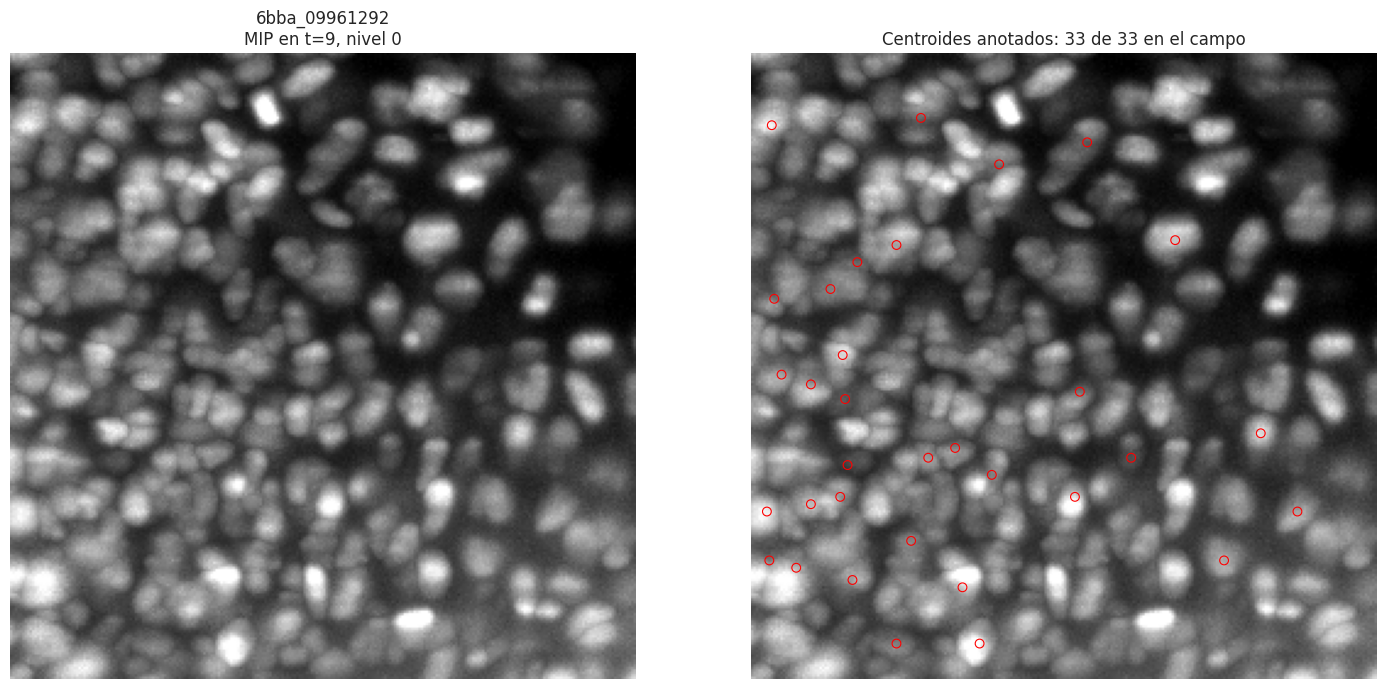

In [61]:
# --- Proyección de máxima intensidad con los centroides anotados encima ------
arr = zarr.open(str(TRAIN_DIR / f"{VIS_SAMPLE}.zarr" / VIS_LEVEL), mode="r")
y0, y1 = crop_y if crop_y else (0, meta["shape"][2])
x0, x1 = crop_x if crop_x else (0, meta["shape"][3])
vol = np.asarray(arr[VIS_T, :, y0:y1, x0:x1])
mip = vol.max(axis=0)

# Los centroides están en píxeles del nivel 0: se reescalan al nivel descargado.
shape0 = niveles["0"]["shape"] if "0" in niveles else meta["shape"]
fy, fx = shape0[2] / meta["shape"][2], shape0[3] / meta["shape"][3]

n = df_nodes[(df_nodes["sample"] == VIS_SAMPLE) & (df_nodes["t"] == VIS_T)]
py, px = n["y"] / fy - y0, n["x"] / fx - x0
dentro = (py >= 0) & (py < mip.shape[0]) & (px >= 0) & (px < mip.shape[1])

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].imshow(mip, cmap="gray", vmin=np.percentile(mip, 1), vmax=np.percentile(mip, 99.5))
ax[0].set_title(f"{VIS_SAMPLE}\nMIP en t={VIS_T}, nivel {VIS_LEVEL}"); ax[0].axis("off")

ax[1].imshow(mip, cmap="gray", vmin=np.percentile(mip, 1), vmax=np.percentile(mip, 99.5))
ax[1].scatter(px[dentro], py[dentro], s=40, facecolor="none", edgecolor="red", lw=.8)
ax[1].set_title(f"Centroides anotados: {int(dentro.sum())} de {len(n)} en el campo")
ax[1].axis("off")
plt.tight_layout(); plt.show()

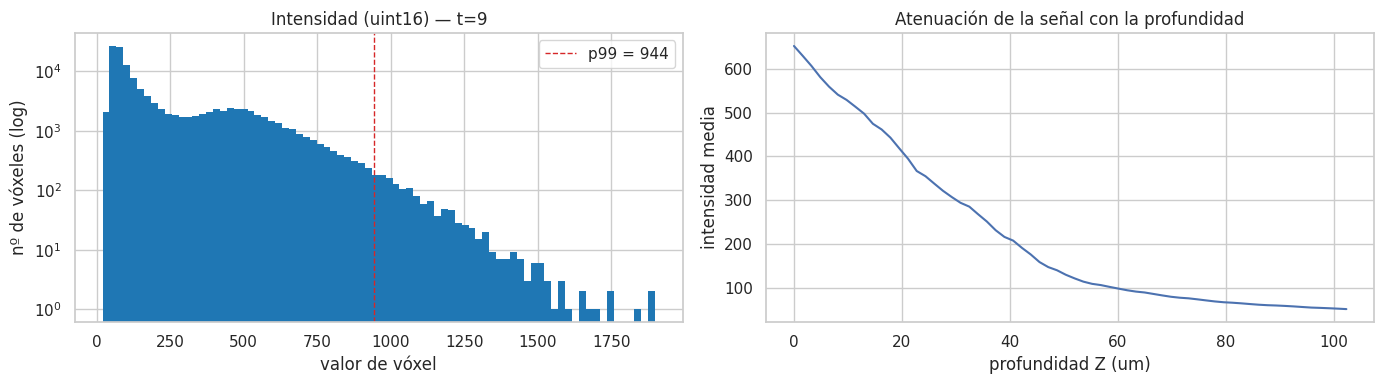

Rango: 15 – 2052 (3.1% del rango del uint16)
Mediana (fondo): 110 | p99: 944 | p99.9: 1262
Vóxeles por encima del p99: 1.00%
Atenuación: la intensidad media cae de 652 en la superficie a 52 en el fondo (92% de pérdida)


In [62]:
# --- Distribución de intensidades -------------------------------------------
muestra_px = np.asarray(vol[::2, ::4, ::4]).ravel()
p99 = np.percentile(muestra_px, 99)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].hist(muestra_px, bins=80, log=True, color="tab:blue", edgecolor="none")
ax[0].axvline(p99, ls="--", lw=1, color="tab:red", label=f"p99 = {p99:.0f}")
ax[0].set_title(f"Intensidad ({vol.dtype}) — t={VIS_T}")
ax[0].set_xlabel("valor de vóxel"); ax[0].set_ylabel("nº de vóxeles (log)")
ax[0].legend()

perfil = vol.reshape(vol.shape[0], -1).mean(axis=1)
ax[1].plot(np.arange(len(perfil)) * VOXEL_UM[0] * (shape0[1] / meta["shape"][1]), perfil)
ax[1].set_xlabel("profundidad Z (um)"); ax[1].set_ylabel("intensidad media")
ax[1].set_title("Atenuación de la señal con la profundidad")

plt.tight_layout(); plt.show()

print(f"Rango: {vol.min()} – {vol.max()} ({(vol.max()/65535)*100:.1f}% del rango del uint16)")
print(f"Mediana (fondo): {np.median(muestra_px):.0f} | p99: {p99:.0f} | "
      f"p99.9: {np.percentile(muestra_px, 99.9):.0f}")
print(f"Vóxeles por encima del p99: {(muestra_px > p99).mean()*100:.2f}%")
print(f"Atenuación: la intensidad media cae de {perfil[0]:.0f} en la superficie "
      f"a {perfil[-1]:.0f} en el fondo ({(1-perfil[-1]/perfil[0])*100:.0f}% de pérdida)")

Los centroides anotados caen sobre núcleos visibles, lo que confirma la conversión de unidades y el
orden de los ejes. También se ven muchos núcleos sin anotar, coherente con la densidad de 5.4. En este
volumen se usa solo el 3.1% del rango de `uint16`, y la intensidad media cae 92% entre la superficie y
el fondo. **Estas cifras salen de un solo volumen**, y 5.10.b muestra que la atenuación del 92% no es
representativa.

### 5.10.b Intensidad y atenuación en varias muestras

Se leen `N_IMG_POR_EMBRION` muestras al azar de cada embrión, en tres instantes (inicio, mitad y
final). Para cada volumen se calculan percentiles de intensidad y el perfil medio por plano Z. Eso
permite comprobar si la atenuación y el rango dinámico son generales, si difieren entre embriones y si
la señal se pierde con el tiempo (fotoblanqueo).

Leyendo volúmenes:   0%|          | 0/20 [00:00<?, ?it/s]

Volúmenes leídos: 60 (20 muestras x 3 instantes)



embryo_id               44b6    6bba
mediana       median   500.5    96.0
              min       57.0    25.0
              max     1936.0   372.0
p99           median  2165.0   710.0
              min      781.0   358.0
              max     3869.0  2103.0
max           median  3471.5  1774.0
              min     1874.0   793.0
              max     6800.0  4126.0
rango_usado_% median     5.3     2.7
              min        2.9     1.2
              max       10.4     6.3
atenuacion_%  median    12.8    34.8
              min     -442.2  -267.4
              max       95.7    89.6


Fotoblanqueo — p99 mediano por instante:
t              0       50      99
embryo_id                        
44b6       1574.0  2368.0  2648.0
6bba        642.0   750.0   892.0


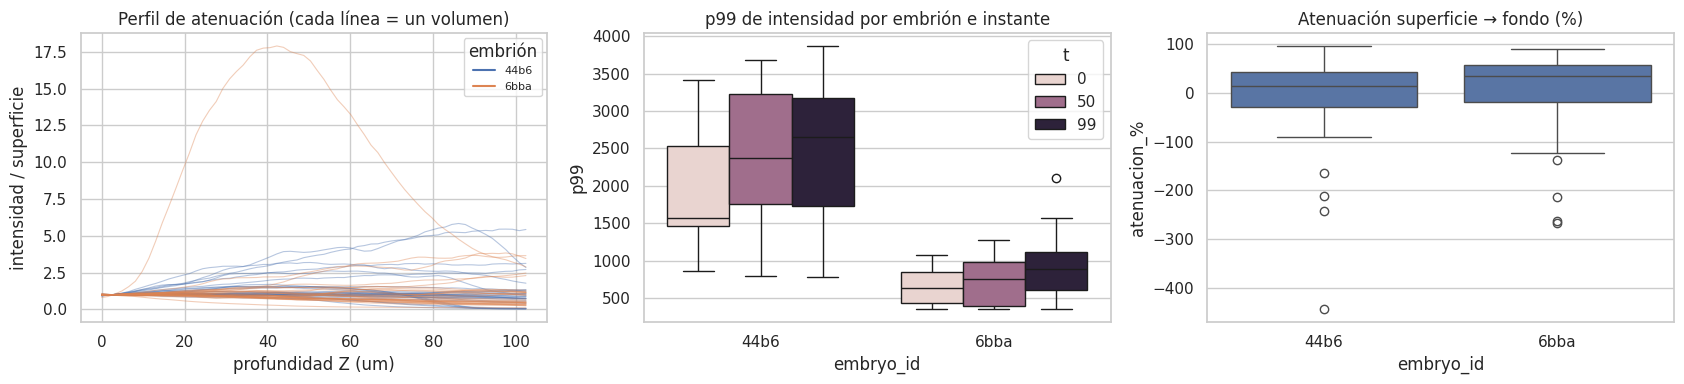

In [63]:
N_IMG_POR_EMBRION = 10          # volúmenes por embrión (cada instante pesa ~8 MB sin comprimir)
T_IMG = (0, 50, 99)             # inicio, mitad y final del video

rng = np.random.default_rng(0)
filas_img, perfiles = [], []
pares = [(e, s) for e, g in df_samples.groupby("embryo_id")
         for s in rng.choice(g["sample"].to_numpy(), min(N_IMG_POR_EMBRION, len(g)), replace=False)]

for e, s in tqdm(pares, desc="Leyendo volúmenes"):
    arr = zarr.open(str(TRAIN_DIR / f"{s}.zarr" / "0"), mode="r")
    for t in T_IMG:
        if t >= arr.shape[0]:
            continue
        v = np.asarray(arr[t])
        perfil_z = v.reshape(v.shape[0], -1).mean(axis=1)
        p1, p50, p99, p999 = np.percentile(v[:, ::4, ::4], [1, 50, 99, 99.9])
        filas_img.append({"sample": s, "embryo_id": e, "t": t, "p1": p1, "mediana": p50, "p99": p99,
                          "p99.9": p999, "max": int(v.max()),
                          # promedio de los 4 primeros y últimos planos: más robusto que un solo plano
                          "media_superficie": perfil_z[:4].mean(), "media_fondo": perfil_z[-4:].mean()})
        perfiles.append(pd.DataFrame({"sample": s, "embryo_id": e, "t": t,
                                      "z_um": np.arange(len(perfil_z)) * VOXEL_UM[0],
                                      "rel": perfil_z / perfil_z[:4].mean()}))

df_img = pd.DataFrame(filas_img)
df_img["atenuacion_%"] = (1 - df_img["media_fondo"] / df_img["media_superficie"]) * 100
df_img["rango_usado_%"] = df_img["max"] / np.iinfo(np.uint16).max * 100
df_perfil = pd.concat(perfiles, ignore_index=True)

print(f"Volúmenes leídos: {len(df_img)} ({df_img['sample'].nunique()} muestras x {len(T_IMG)} instantes)\n")
display(df_img.groupby("embryo_id")[["mediana", "p99", "max", "rango_usado_%", "atenuacion_%"]]
        .agg(["median", "min", "max"]).T.round(1))
print("\nFotoblanqueo — p99 mediano por instante:")
print(df_img.pivot_table(index="embryo_id", columns="t", values="p99", aggfunc="median").round(0))

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
for (s, t), g in df_perfil.groupby(["sample", "t"]):
    ax[0].plot(g["z_um"], g["rel"], lw=.8, alpha=.4, color=COLOR_EMB[g["embryo_id"].iat[0]])
ax[0].set_xlabel("profundidad Z (um)"); ax[0].set_ylabel("intensidad / superficie")
ax[0].set_title("Perfil de atenuación (cada línea = un volumen)"); leyenda_embriones(ax[0])

sns.boxplot(data=df_img, x="embryo_id", y="p99", hue="t", ax=ax[1])
ax[1].set_title("p99 de intensidad por embrión e instante")
sns.boxplot(data=df_img, x="embryo_id", y="atenuacion_%", ax=ax[2])
ax[2].set_title("Atenuación superficie → fondo (%)")
plt.tight_layout(); plt.show()

**Resultado: la atenuación del informe no es representativa.**

- **Atenuación variable.** La atenuación superficie → fondo tiene mediana **13% en 44b6 y 35% en
  6bba**, con un rango de −442% a 96%. El 92% del volumen usado en el informe (`6bba_09961292`,
  t = 9) está en el extremo alto.
- **Z = 0 no siempre es la superficie.** Los valores negativos son volúmenes más brillantes en el
  fondo que arriba. Uno de 6bba tiene su máximo a ~45 µm, 17 veces más brillante que la superficie: la
  posición del tejido dentro del recorte cambia de una muestra a otra.
- **44b6 es unas 3 veces más brillante.** p99 mediano de 2,165 vs 710 y máximo mediano de 3,472 vs
  1,774. Aun así, la señal ocupa poco del rango de `uint16` (3.3% mediano, 10.4% como máximo).
- **No hay fotoblanqueo; la señal aumenta con el tiempo.** El p99 mediano sube de 1,574 a 2,648 en
  44b6 (+68%) y de 642 a 892 en 6bba (+39%) entre t = 0 y t = 99. Puede deberse a más núcleos en el
  campo o a mayor expresión del marcador fluorescente; con estos datos no se distingue.

**Implicación para el preprocesamiento.** Una corrección fija de atenuación en Z no se justifica. Lo
que sí hace falta es **normalizar cada volumen, en cada instante, con cuantiles** (por ejemplo
p1 – p99.9), porque el brillo cambia entre embriones, entre muestras y en el tiempo. Una normalización
global (dividir entre el máximo de `uint16` o entre un valor fijo) dejaría volúmenes no comparables.

## 5.11 Estabilidad de los resultados: 30 vs 199 muestras

Esta sección corresponde a la 4.2 del informe, que comparaba 8 contra 30 muestras. Aquí se
recalculan las métricas principales sobre **las mismas 30 muestras** del informe (las 15 primeras de
cada embrión, en orden alfabético) y sobre las 199. La columna de 30 debe reproducir las cifras del
informe (2.05%, 20 divisiones, p99 = 8.35 µm, máx. = 17.97 µm); eso sirve como verificación de que el
código es el mismo.

In [64]:
ORIG30 = [s for e in sorted(by_embryo) for s in sorted(by_embryo[e])[:15] if s in set(SAMPLES)]
EMB = list(df_samples["embryo_id"].value_counts().index)


def metricas(muestras):
    S = df_samples[df_samples["sample"].isin(muestras)]
    E = df_edges[df_edges["sample"].isin(muestras) & (df_edges.dt == 1)]
    q1, q3 = E["dist_um"].quantile([.25, .75])
    atip = E["dist_um"] > q3 + 1.5 * (q3 - q1)
    div = E["out_degree_origen"] >= 2
    r = {
        "muestras": len(S),
        "nodos": int(S["n_nodos"].sum()),
        "densidad global (%)": S["n_nodos"].sum() / S["estimated_number_of_nodes"].sum() * 100,
        "desplazamiento p50 (um)": E["dist_um"].median(),
        "desplazamiento p99 (um)": E["dist_um"].quantile(.99),
        "desplazamiento máx (um)": E["dist_um"].max(),
        "atípicos Tukey (%)": atip.mean() * 100,
        "atípicos en aristas de división (%)": atip[div].mean() * 100 if div.any() else np.nan,
        "divisiones": int(S["n_divisiones"].sum()),
        "muestras con división": int((S["n_divisiones"] > 0).sum()),
    }
    for e in EMB:
        r[f"desplaz. mediano {e} (um)"] = E.loc[E.embryo_id == e, "dist_um"].median()
        r[f"densidad media {e} (%)"] = S.loc[S.embryo_id == e, "densidad_anotacion"].mean()
    return pd.Series(r)


estab = pd.DataFrame({"30 muestras (informe)": metricas(ORIG30), f"{len(SAMPLES)} muestras": metricas(SAMPLES)})
estab["cambio (%)"] = (estab.iloc[:, 1] / estab.iloc[:, 0] - 1) * 100
estab.round(2)

,30 muestras (informe),199 muestras,cambio (%)
muestras,30.00,199.00,563.33
nodos,15934.00,133318.00,736.69
densidad global (%),2.05,2.82,37.86
desplazamiento p50 (um),1.86,1.82,-2.41
desplazamiento p99 (um),8.35,8.38,0.44
desplazamiento máx (um),17.97,60.76,238.17
atípicos Tukey (%),3.98,4.70,18.27
atípicos en aristas de división (%),42.50,54.30,27.78
divisiones,20.00,151.00,655.00
muestras con división,12.00,87.00,625.00


**Lectura.** Los cuantiles centrales del movimiento (p50, p99) son estables: el radio de búsqueda que
proponía el informe sigue siendo válido. Lo que cambia son las cantidades que dependen de eventos
raros o de la cola: el máximo, el número de divisiones y el porcentaje de atípicos en divisiones. Por
eso ampliar a 199 muestras era necesario para hablar de divisiones y de atípicos extremos.

# 6. Hallazgos y conclusiones

In [65]:
# Resumen numérico listo para copiar al informe
e1 = df_edges[df_edges.dt == 1]
nodos_por_t = df_nodes.groupby(["sample", "t"]).size()
dims = tuple(int(v) for v in df_samples.iloc[0][["T", "Z", "Y", "X"]])
dtipo = df_samples["dtype"].iloc[0]
tasa_div = df_nodes["es_division"].mean()
dens_glob = df_samples.n_nodos.sum() / df_samples.estimated_number_of_nodes.sum() * 100

por_embrion = (df_nodes.groupby("embryo_id").size().rename("nodos").to_frame()
               .join(e1.groupby("embryo_id")["dist_um"].median().rename("desplaz_mediana_um"))
               .round(2).to_string())

print(f"""
DATOS ANALIZADOS
  Muestras: {len(df_samples)} de {df_samples.embryo_id.nunique()} embriones distintos
  Dimensiones (T, Z, Y, X): {dims} | dtype: {dtipo}
  Escala del vóxel: {tuple(VOXEL_UM.tolist())} um -> anisotropía {VOXEL_UM[0]/VOXEL_UM[1]:.0f}x en Z
  Nodos: {len(df_nodes):,} | Aristas: {len(df_edges):,} | Linajes: {len(df_linajes):,}

DENSIDAD Y ESPARCIDAD DE LA ANOTACIÓN
  Nodos por instante: mediana {nodos_por_t.median():.0f} (rango {nodos_por_t.min()}-{nodos_por_t.max()})
  Cobertura temporal media: {df_samples.cobertura_temporal.mean()*100:.1f}% de los frames del video
  Densidad de anotación global: {dens_glob:.2f}% de las células estimadas
    (por muestra: {df_samples.densidad_anotacion.min():.2f}% - {df_samples.densidad_anotacion.max():.2f}%)
  Aristas por nodo: {df_samples.aristas_por_nodo.mean():.2f}

DINÁMICA CELULAR (enlaces con dt=1)
  Desplazamiento: mediana {e1.dist_um.median():.2f} um | p95 {e1.dist_um.quantile(.95):.2f} um
                  p99 {e1.dist_um.quantile(.99):.2f} um | máximo {e1.dist_um.max():.2f} um
  Duración de linajes: mediana {df_linajes.duracion.median():.0f} frames | máx {df_linajes.duracion.max():.0f}

DIVISIONES
  {int(df_nodes.es_division.sum()):,} eventos = {tasa_div*100:.3f}% de los nodos
  Desbalance aproximado 1:{int(1/max(tasa_div, 1e-9)):,}

VARIABILIDAD ENTRE EMBRIONES
{por_embrion}
""")

# Complementos de esta versión (secciones 5.7 y 5.10.b)
if "posible_error" in df_edges:
    print(f"ATÍPICOS EXTREMOS\n  Aristas marcadas como posible error de anotación: "
          f"{int(df_edges['posible_error'].sum()):,} de {len(df_edges):,}")
if "salto_instante" in df_edges:
    print(f"  Aristas en instantes con salto colectivo: {int(df_edges['salto_instante'].sum()):,} "
          f"({len(saltos)} instantes en {saltos['sample'].nunique()} muestras)")
if "df_img" in dir() and len(df_img):
    print(f"\nIMAGEN ({df_img['sample'].nunique()} muestras x {len(T_IMG)} instantes)\n"
          f"  Atenuación superficie → fondo: mediana {df_img['atenuacion_%'].median():.0f}% "
          f"(rango {df_img['atenuacion_%'].min():.0f}–{df_img['atenuacion_%'].max():.0f}%)\n"
          f"  Rango de uint16 usado: mediana {df_img['rango_usado_%'].median():.1f}%")


DATOS ANALIZADOS
  Muestras: 199 de 2 embriones distintos
  Dimensiones (T, Z, Y, X): (100, 64, 256, 256) | dtype: uint16
  Escala del vóxel: (1.625, 0.40625, 0.40625) um -> anisotropía 4x en Z
  Nodos: 133,318 | Aristas: 128,883 | Linajes: 4,435

DENSIDAD Y ESPARCIDAD DE LA ANOTACIÓN
  Nodos por instante: mediana 6 (rango 1-33)
  Cobertura temporal media: 95.1% de los frames del video
  Densidad de anotación global: 2.82% de las células estimadas
    (por muestra: 0.13% - 20.21%)
  Aristas por nodo: 0.97

DINÁMICA CELULAR (enlaces con dt=1)
  Desplazamiento: mediana 1.82 um | p95 5.34 um
                  p99 8.38 um | máximo 60.76 um
  Duración de linajes: mediana 21 frames | máx 100

DIVISIONES
  151 eventos = 0.113% de los nodos
  Desbalance aproximado 1:882

VARIABILIDAD ENTRE EMBRIONES
            nodos  desplaz_mediana_um
embryo_id                            
44b6        20197                1.72
6bba       113121                1.82

ATÍPICOS EXTREMOS
  Aristas marcadas como p

## 6.1 Resumen de hallazgos (199 muestras)

- **Cobertura parcial y heterogénea.** Está anotado el 2.82% de las células estimadas, con valores de
  0.13% a 20.21% entre muestras. 6bba promedia 8.98% y 44b6 0.99%. Es supervisión parcial: las células
  no anotadas no son faltantes ni fondo.
- **Geometría anisotrópica y coordenadas cuantizadas.** Vóxel de 1.625 × 0.40625 × 0.40625 µm
  (4:1 en Z). Las distancias deben calcularse en micras, y la referencia tiene una incertidumbre de
  ±0.81 µm en Z y ±0.20 µm en XY.
- **Movimiento pequeño y estable.** Mediana 1.82 µm y p99 8.38 µm, prácticamente iguales a los de 30
  muestras. Un radio inicial de ≈ 8.4 µm cubre el 99% de los enlaces y sirve para ambos embriones.
- **Deriva direccional.** Esto corrige al informe. Los pasos en Z van 2:1 hacia Z negativo, con una
  deriva de −0.52 µm/frame en 6bba y −0.21 en 44b6, presente en ~70% de las muestras. Es pequeña frente
  al radio, pero sistemática; el enlace debería compensarla.
- **Atípicos ligados a divisiones.** El 54.3% de las aristas que salen de una división son atípicas,
  frente al 4.6% del resto. Recortar el radio de búsqueda perjudicaría justamente a las divisiones.
- **Pocos errores puntuales.** Solo el 0.05% de las aristas son saltos de ida y vuelta, y su efecto
  sobre la distribución es nulo. Los valores de 49 – 61 µm vienen de un único salto colectivo en una
  muestra (5.7.b).
- **Divisiones escasas.** 151 eventos (0.113%, ≈ 1:882), presentes en 87 de 199 muestras y con tasa
  similar en ambos embriones. Se necesitan estrategias para clases desbalanceadas.
- **Los embriones difieren en anotación, no en movimiento.** Desplazamiento de 1.72 vs 1.82 µm
  (p = 0.51) frente a una densidad de 0.77% vs 9.7% (p ≈ 10⁻²⁸). 6bba concentra el 84.9% de los nodos.
- **Intensidad variable.** Esto también corrige al informe. La atenuación con la profundidad es
  moderada y muy variable (mediana 13 – 35%, no 92%), 44b6 es ~3 veces más brillante y la señal crece
  con el tiempo (+39 a +68%). Hay que normalizar por volumen y por instante.
- **Integridad.** Sin faltantes, duplicados, coordenadas fuera de rango ni aristas con `dt ≠ 1`.

> ⏳ **Pendiente**: agregar el resultado de 5.7.b (si el salto colectivo es de la imagen o de la
> anotación).

## 6.2 Limitaciones

- **Solo dos embriones.** Las comparaciones entre individuos no se pueden generalizar, y el conjunto
  de prueba usa embriones distintos.
- **Desbalance entre embriones.** 6bba aporta el 85% de los nodos, así que las métricas globales
  reflejan sobre todo a ese embrión. Por eso se reportan también por embrión.
- **Análisis de imagen sobre una submuestra.** Son 20 volúmenes (10 por embrión) en tres instantes,
  no el video completo. Alcanza para mostrar que la intensidad es variable, pero no para modelar esa
  variación.
- **Causa de la deriva.** Los datos no permiten distinguir si viene de flujos del tejido o de la
  adquisición.

## 6.3 Próximos pasos

1. Establecer una línea base de detección con un filtro Laplaciano de Gauss y compararla con una U-Net
   3D que incorpore la anisotropía, en la arquitectura o en el remuestreo de entrada.
2. Implementar una línea base de enlace con asignación lineal (algoritmo húngaro), con costos en
   micras, un radio inicial de ≈ 8.4 µm estimado **sin** las aristas marcadas como `posible_error` o
   `salto_instante`, y **predicción de posición con la deriva local** (desplazamiento medio por muestra
   e instante). Luego, medir la sensibilidad de precisión y recuperación frente a distintos radios.
3. Modelar las divisiones como una tarea desbalanceada y evaluarlas con métricas de la clase
   minoritaria.
4. Normalizar la intensidad por cuantiles en cada volumen y en cada instante, en lugar de usar una
   escala global o una corrección fija en Z.
5. Si 5.7.b confirma saltos de adquisición, agregar un paso de registro entre instantes antes del
   enlace.
6. Particionar por `embryo_id` y reportar explícitamente la incertidumbre de tener solo dos embriones.